# Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import umap

/home/chucho/Projects/Realistic_TCMS_simulation/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [61]:
#nomi delle colonne da generare
columns_to_generate = [
    'Durata','CabEnabled_M1', 'CabEnabled_M8', 'ERTMS_PiastraSts', 'HMI_ACPntSts_T2', 'HMI_ACPntSts_T7', 'HMI_DCPntSts_T2',
    'HMI_DCPntSts_T7', 'HMI_Iline', 'HMI_Irsts_T2', 'HMI_Irsts_T7', 'HMI_VBatt_T2', 'HMI_VBatt_T4', 'HMI_VBatt_T5',
    'HMI_VBatt_T7', 'HMI_Vline', 'HMI_impSIL', 'LineVoltType', 'MDS_LedLimVel', 'MDS_StatoMarcia', '_GPS_LAT',
    '_GPS_LON', 'ldvvelimps', 'ldvveltreno', 'usB1BCilPres_M1', 'usB1BCilPres_M3', 'usB1BCilPres_M6', 'usB1BCilPres_M8',
    'usB1BCilPres_T2', 'usB1BCilPres_T4', 'usB1BCilPres_T5', 'usB1BCilPres_T7', 'usB2BCilPres_M1', 'usB2BCilPres_M3',
    'usB2BCilPres_M6', 'usB2BCilPres_M8', 'usB2BCilPres_T2', 'usB2BCilPres_T4', 'usB2BCilPres_T5', 'usB2BCilPres_T7',
    'usBpPres', 'usMpPres'
]

non_numeric_cols = [
        'Descrizione',
        'Timestamp chiusura',
        'Posizione',
        'Flotta',
        'Veicolo',
        'Codice',
        'Nome',
        'Test',
        'Sistema',
        'Componente',
        'Timestamp segnale']

In [3]:
dataset = pd.read_csv('dataset.csv')
print('intial dataset len', len(dataset), 'column num', len(dataset.columns))
dataset_new = dataset.copy()
dataset_new['Timestamp'] = pd.to_datetime(dataset_new['Timestamp'], errors='coerce')
# timestamp will be essential
dataset_new = dataset_new.dropna(subset=['Timestamp'])
# repeated signals:
dataset_new = dataset_new.drop_duplicates(subset=['Descrizione', 'Timestamp'])
dataset_new.set_index('Timestamp', inplace=True)
dataset_new = dataset_new.dropna(axis=1, how='all')
dataset_new = dataset_new.dropna()
print('after first filtering dataset len', len(dataset_new), 'column num', len(dataset_new.columns))

intial dataset len 57652 column num 169
after first filtering dataset len 12350 column num 56


# Preliminary dataset analysis:

## some plots:

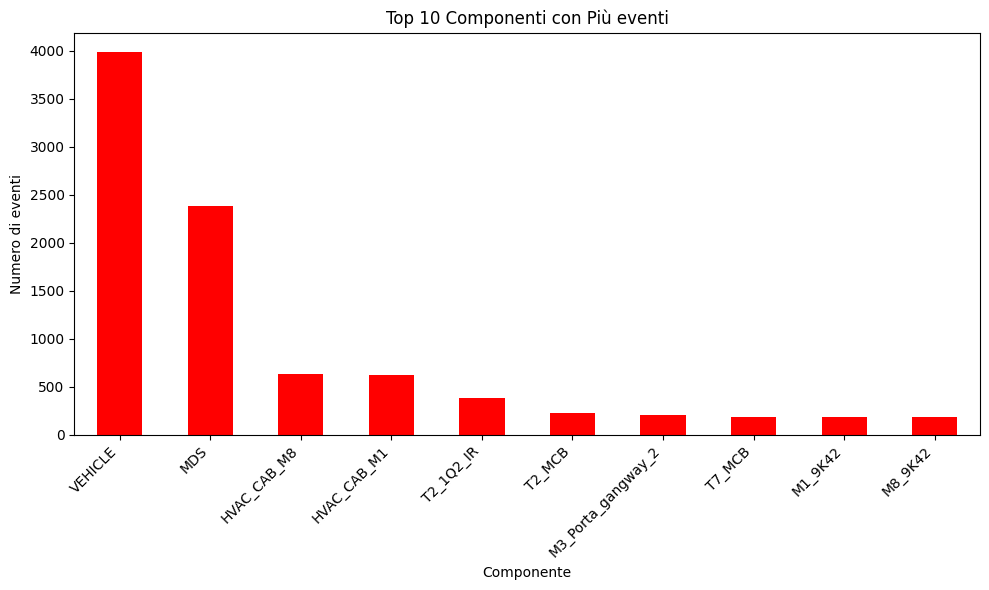

In [4]:
# popular "componente"
eventi_per_sistema = dataset_new.groupby(['Componente']).count()['Flotta']

top_events = eventi_per_sistema.nlargest(10)
plt.figure(figsize=(10, 6))
top_events.plot(kind='bar', color='red')
plt.title('Top 10 Componenti con Più eventi')
plt.xlabel('Componente')
plt.ylabel('Numero di eventi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



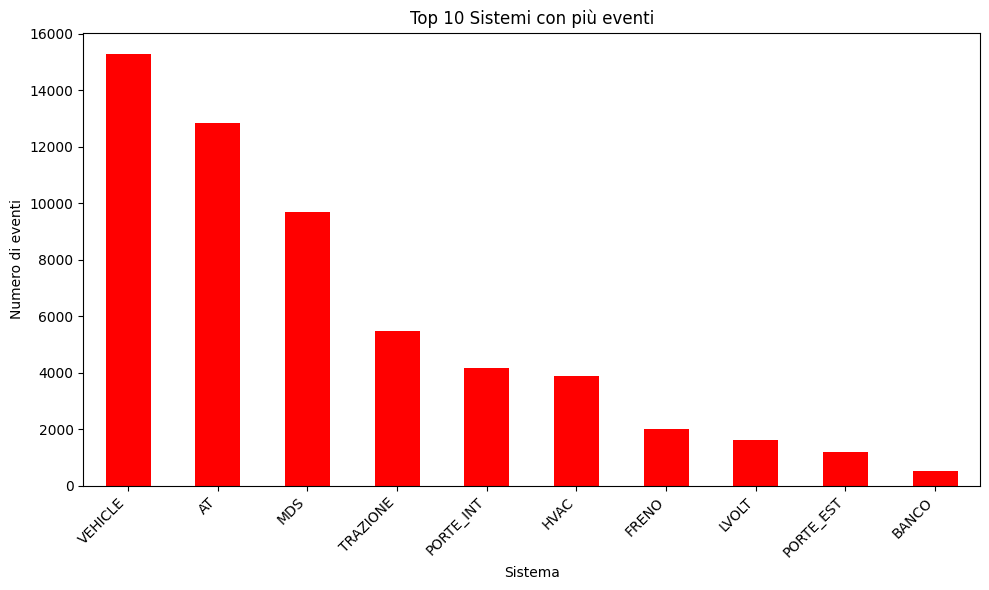

In [5]:
# popular "sistema"
eventi_per_sistema = dataset.groupby(['Sistema']).count()['Flotta']

top_events = eventi_per_sistema.nlargest(10)
plt.figure(figsize=(10, 6))
top_events.plot(kind='bar', color='red')
plt.title('Top 10 Sistemi con più eventi')
plt.xlabel('Sistema')
plt.ylabel('Numero di eventi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



### some other observations:

In [67]:
dataset_new[non_numeric_cols].nunique()

Descrizione             310
Timestamp chiusura    10186
Posizione                95
Flotta                    1
Veicolo                   1
Codice                  430
Nome                    247
Test                      1
Sistema                  16
Componente              151
Timestamp segnale      6709
dtype: int64

In [68]:
dataset_new.groupby(['Codice','Nome','Descrizione'])['Flotta'].count()

Codice            Nome              Descrizione                                      
010085            PntLow3           Abbassamento pantogr. comandato da ERTMS              24
010088            PntLow6           Guasto trasduttore TVL                                 1
010090            PntLow8           Abbassamento pantogr. per guasto IR                    1
010098            PntLow16          Abbassamento pantogr. per incongruenza linea           1
011050            _HVACcabNotOK_    Perdita di comunicazione con HVAC cabina M1          614
                                                                                        ... 
ILCK_Panto_T7_19  ILCK_Panto_T7_19  Cod 19. Contattore 1Q1 non aperto                      1
ILCK_Panto_T7_26  ILCK_Panto_T7_26  Cod 26. Guasto sensore Tensione di Linea               1
ILCK_Panto_T7_42  ILCK_Panto_T7_42  Cod 42. Incoerenza Tensione di Linea TCU M8            1
ILCK_Panto_T7_43  ILCK_Panto_T7_43  Cod 43. Incoerenza Tensione di Linea TCU 

In [69]:
dataset_new.groupby(['Posizione'])['Flotta'].count()

Posizione
Antegnate                31
Aurisina                  2
Aurisina Cave             5
Botticino                42
Brendola                 37
                       ... 
Verona                  448
Vicenza                 452
Villafranca Padovana      7
Vimodrone                53
Visogliano                4
Name: Flotta, Length: 95, dtype: int64

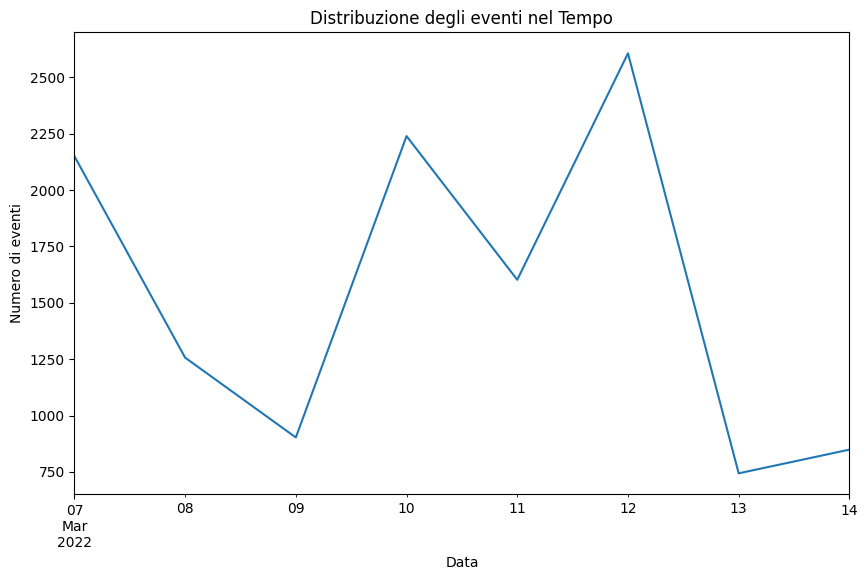

In [70]:
#visualizzazione della distribazione degli eventi nel tempo
dataset_new.resample('D').size().plot(title='Distribuzione degli eventi nel Tempo', figsize=(10, 6))
plt.xlabel('Data')
plt.ylabel('Numero di eventi')
plt.show()

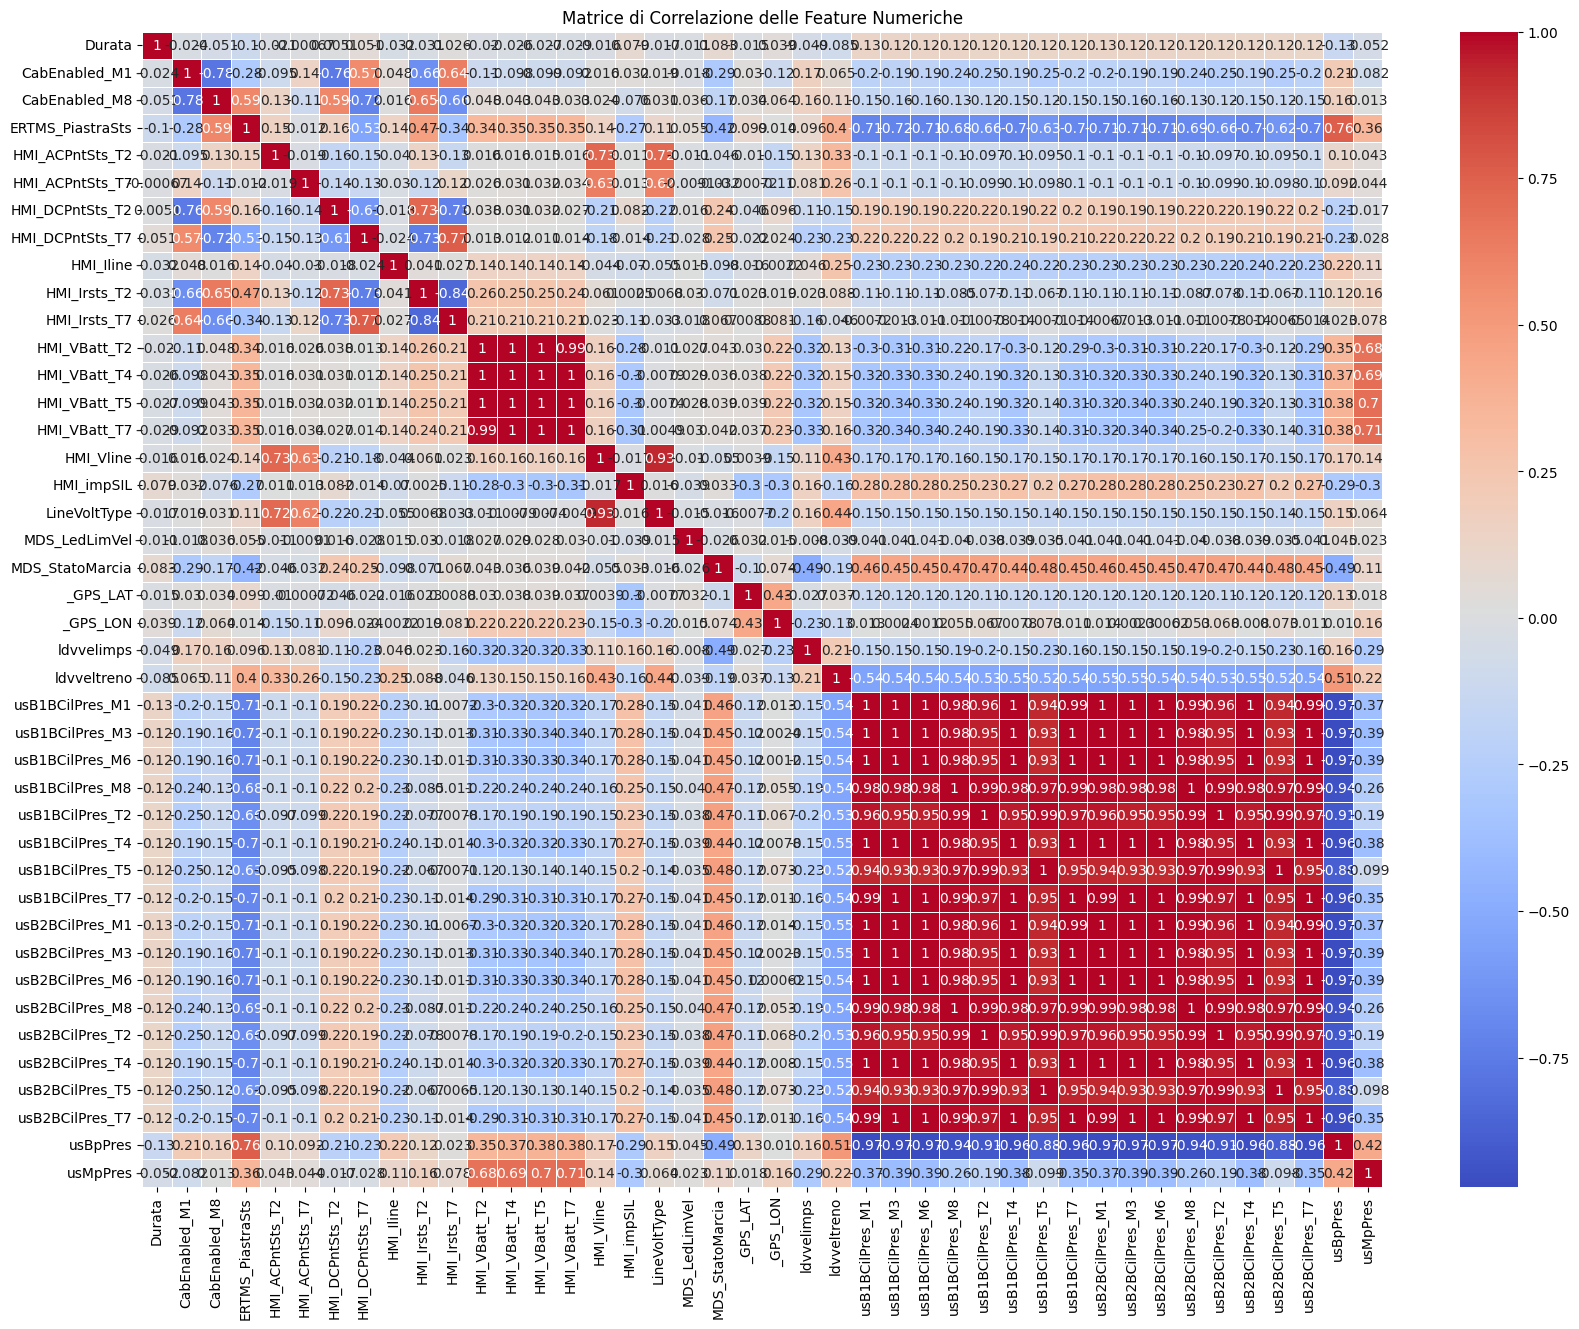

In [71]:
#matrice di correlazione
correlation_matrix = dataset_new[columns_to_generate].corr()
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matrice di Correlazione delle Feature Numeriche')
plt.show()

## Looking for statistical correlations 


______________________

Premise: 
- we are not taking into account the time-series nature of data, just tabular stuff.
- between numerical (i.e. from sensors) and non-numerical (i.e. from labels) data.
- "correlation" is intended ALSO in the non-linear setting. (we use UMAP)

Let's create a non linear 2D reduction of the numerical data at hand:

/home/chucho/Projects/Realistic_TCMS_simulation/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/chucho/Projects/Realistic_TCMS_simulation/venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/chucho/Projects/Realistic_TCMS_simulation/venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


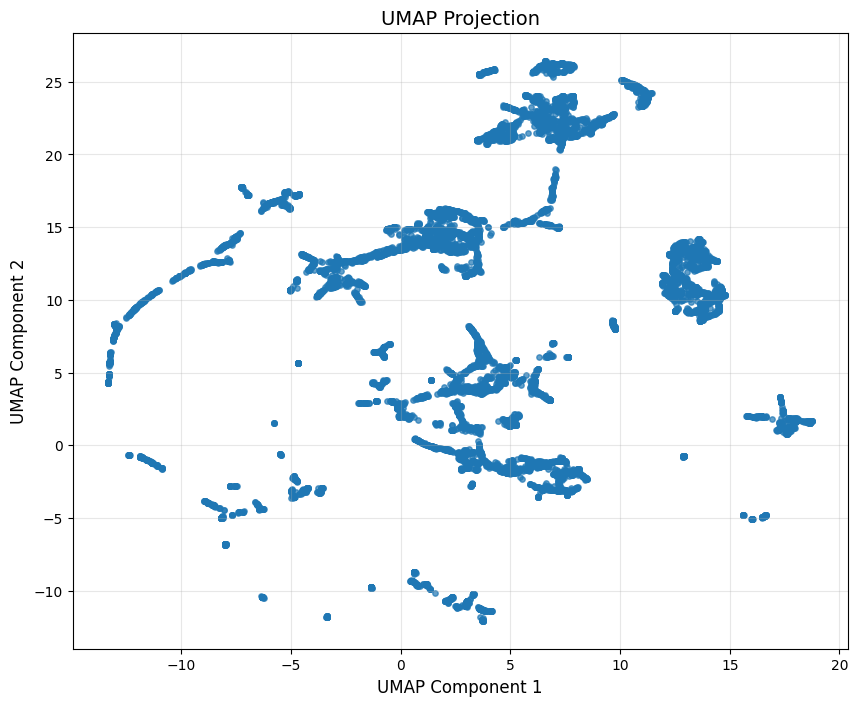

In [6]:
X = dataset_new[columns_to_generate].values
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
# Fit and transform the data
embedding = reducer.fit_transform(X.reshape(X.shape[0], -1))

plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], s=15, alpha=0.7)
plt.title('UMAP Projection', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


In [7]:
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.optim as optim


class MLP(nn.Module):
    def __init__(self, **kwargs):
        super(MLP, self).__init__()
        input_dim = kwargs.get('input_dim', 40)
        h_dim = kwargs.get('h_dim', 128)
        dropout = kwargs.get('dropout', 0.1)
        num_layers = kwargs.get('num_layers', 3)
        layer_norm = kwargs.get('layer_norm', False)
        output_dim = kwargs.get('output_dim',1)
        self.mode = kwargs.get('mode')
        
        main_stream = []

        if layer_norm:
            main_stream.append(nn.LayerNorm(input_dim))
        
        curr_output_dim = h_dim
        curr_main_input_dim = input_dim

        for _ in range(num_layers):
            main_stream.append(nn.Linear(curr_main_input_dim, curr_output_dim))
            main_stream.append(nn.ReLU())
            main_stream.append(nn.Dropout(dropout))
            curr_main_input_dim = curr_output_dim
            curr_output_dim = curr_output_dim // 2

        # manifold layer:
        curr_output_dim = 2
        self.manifold_layer = nn.Linear(curr_main_input_dim, curr_output_dim)
        curr_main_input_dim = curr_output_dim


        self.output_module = nn.Sequential(
            nn.Linear(curr_main_input_dim, output_dim),
            (nn.Sigmoid() if output_dim == 1 else nn.Softmax(1)))
        
        self.main_stream = nn.Sequential(*main_stream)
        # print("Architecture of the MLP: ")
        # print(self.parameters)
            
    def forward(self, x):
        
        main = self.main_stream(x)
        manifold = self.manifold_layer(main)
        return self.output_module(manifold), manifold.detach()

### Events:


==========Eventi più popolari:==========
Descrizione
Cod. 03 Comando di frenatura da manipolatore attivo      1486
Cod. 13 Leva MC 6S01 non in trazione                     1263
Perdita di comunicazione con HVAC cabina M1              1233
Cod. 04 Condotta Generale scarica                         645
Guasto microswitch porta Gangway 2                        519
Guasto microswitch porta Gangway 1                        381
Cod. 22 Manettino fuori coasting dopo taglio trazione     276
Cod. 05 Taglio trazione da SSB attivo                     255
Pressione CP sotto 8.5 bar in M8 (press. 9S14)            226
Apertura forz. contatt. Convert. Princip. DC              218
Name: Flotta, dtype: int64


Il dataset con i 10 eventi più gettonati è lungo  6502 record
{'Cod. 03 Comando di frenatura da manipolatore attivo': 0, 'Cod. 13 Leva MC 6S01 non in trazione': 1, 'Perdita di comunicazione con HVAC cabina M1': 2, 'Cod. 04 Condotta Generale scarica': 3, 'Guasto microswitch porta Gangway 2': 4, 'Gu

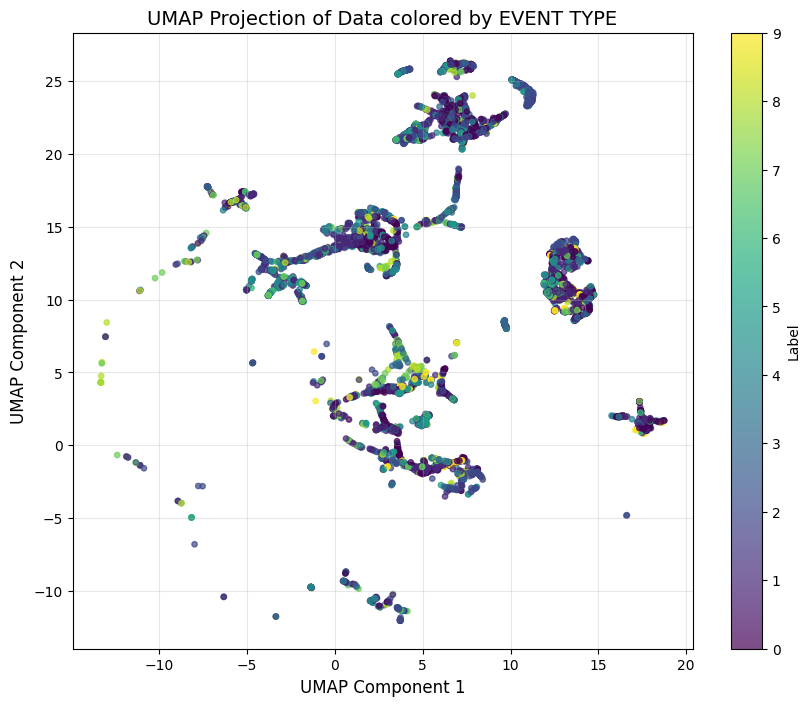

In [16]:
print("==========Eventi più popolari:==========")
print(dataset_new.groupby('Descrizione').count()['Flotta'].nlargest(10))
popular_descriptions = dataset_new.groupby('Descrizione')['Flotta'].count().nlargest(10).index
popular_events_ds = dataset_new[dataset_new['Descrizione'].isin(popular_descriptions)]
print("\n\n","="*50)
print('Il dataset con i 10 eventi più gettonati è lungo ',len(popular_events_ds), 'record')
print("="*50)
description_map = {desc: i for i, desc in enumerate(popular_descriptions)}
descrizioni_numeriche = popular_events_ds['Descrizione'].map(description_map)
print(description_map)

event_embedding = embedding[dataset_new['Descrizione'].isin(popular_descriptions)]
# Visualize the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(event_embedding[:, 0], event_embedding[:, 1], c=descrizioni_numeriche, s=15, alpha=0.7)
plt.title('UMAP Projection of Data colored by EVENT TYPE', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.colorbar(label='Label')
plt.grid(True, alpha=0.3)
plt.show()


Epoch 1, Test Accuracy: 0.2959
Epoch 11, Test Accuracy: 0.3482
Epoch 21, Test Accuracy: 0.3659
Epoch 31, Test Accuracy: 0.3728
Epoch 41, Test Accuracy: 0.3974


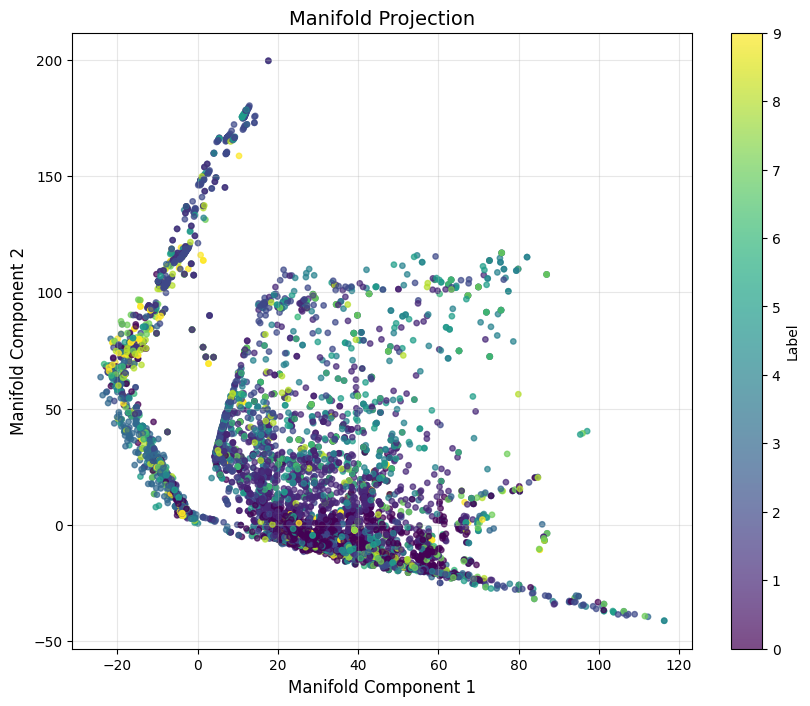

In [24]:
classifier = MLP(
    **{
        'input_dim': X.shape[1],
        'output_dim': 10,
        'layer_norm': True,
        'mode':'OF'})


Y  = descrizioni_numeriche.values
X_event = X[dataset_new['Descrizione'].isin(popular_descriptions)]
X_train, X_test, Y_train, Y_test = train_test_split(X_event, Y, test_size=0.2, random_state=42)

train_scaler = MinMaxScaler()
X_train_scaled = train_scaler.fit_transform(X_train)
X_test_scaled = train_scaler.transform(X_test)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=0.001)

train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_train_scaled).float(),
    torch.tensor(Y_train).long())
test_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_test_scaled).float(),
    torch.tensor(Y_test).long())

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=False)

for epoch in range(50):
    classifier.train()
    for x, y in train_dataloader:
        optimizer.zero_grad()
        output, _ = classifier(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

    classifier.eval()
    total_correct = 0
    with torch.no_grad():
        for x, y in test_dataloader:
            output, _ = classifier(x)
            predicted = torch.argmax(output, dim=1)
            total_correct += (predicted == y).sum().item()
    accuracy = total_correct / len(test_dataset)
    if epoch % 10 == 0:
        print(f'Epoch {epoch+1}, Test Accuracy: {accuracy:.4f}')


all_X_scaled = train_scaler.transform(X_event)
all_X_scaled = torch.Tensor(all_X_scaled).float()
classifier.eval()
all_preds, manifold = classifier(all_X_scaled)
all_preds = (torch.sigmoid(output.squeeze()) > 0.5).long()
manifold = manifold.numpy()

plt.figure(figsize=(10, 8))
plt.scatter(manifold[:, 0], manifold[:, 1], c=Y.astype(int), s=15, alpha=0.7)
plt.title('Manifold Projection', fontsize=14)
plt.xlabel('Manifold Component 1', fontsize=12)
plt.ylabel('Manifold Component 2', fontsize=12)
plt.colorbar(label='Label')

plt.grid(True, alpha=0.3)
plt.show()



### POSITION:




==========Posizioni più popolari:==========
Posizione
Venezia                3906
Milano                 2837
Trieste                 546
Vicenza                 452
Verona                  448
Rovato                  379
Brescia                 375
Treviglio               369
Padova                  337
Peschiera del Garda     204
Name: Flotta, dtype: int64
il dataset con le 10 posizioni più gettonati è le 10 posizioni più gettonate e lungo  12350 record
{'Venezia': 0, 'Milano': 1, 'Trieste': 2, 'Vicenza': 3, 'Verona': 4, 'Rovato': 5, 'Brescia': 6, 'Treviglio': 7, 'Padova': 8, 'Peschiera del Garda': 9}


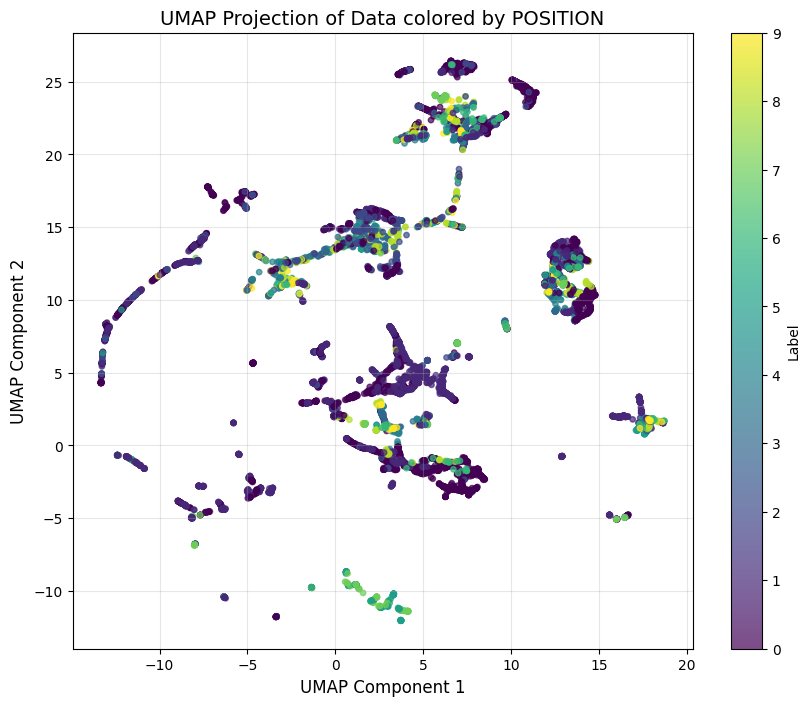

In [9]:
print("\n\n\n==========Posizioni più popolari:==========")
print(dataset_new.groupby('Posizione')['Flotta'].count().nlargest(10))
popular_positions = dataset_new.groupby('Posizione')['Flotta'].count().nlargest(10).index
popular_positions_ds = dataset_new[dataset_new['Posizione'].isin(popular_positions)]
print("="*50)
print('il dataset con le 10 posizioni più gettonati è le 10 posizioni più gettonate e lungo ',len(dataset_new), 'record')
print("="*50)
position_map = {desc: i for i, desc in enumerate(popular_positions)}
posizioni_numeriche = popular_positions_ds['Posizione'].map(position_map)
positions_embedding = embedding[dataset_new['Posizione'].isin(popular_positions)]
print(position_map)
# Visualize the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(positions_embedding[:, 0], positions_embedding[:, 1], c=posizioni_numeriche, s=15, alpha=0.7)
plt.title('UMAP Projection of Data colored by POSITION', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.colorbar(label='Label')
plt.grid(True, alpha=0.3)
plt.show()

Epoch 1, Test Accuracy: 0.4475
Epoch 11, Test Accuracy: 0.8483
Epoch 21, Test Accuracy: 0.8691
Epoch 31, Test Accuracy: 0.8691
Epoch 41, Test Accuracy: 0.8676


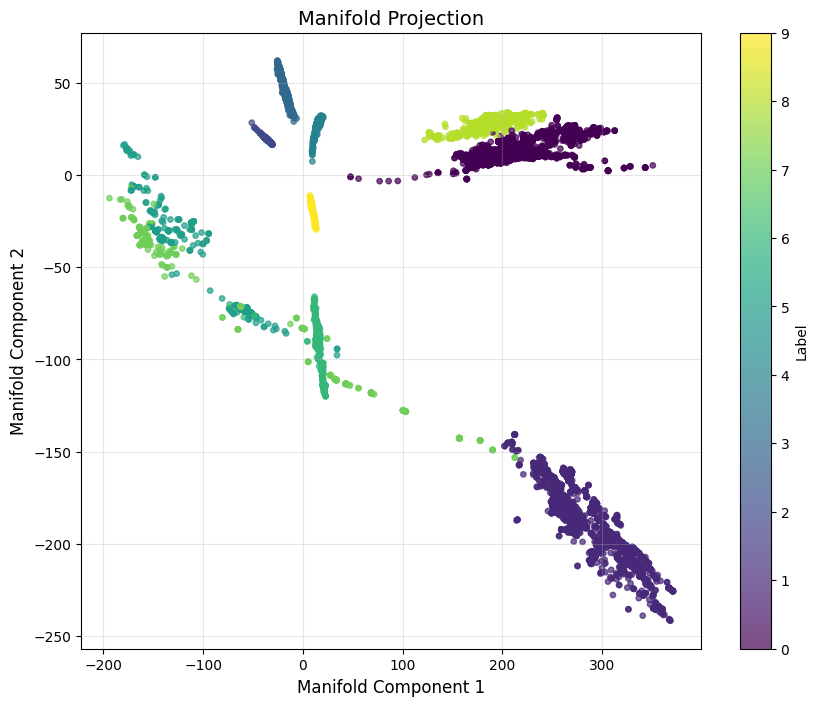

In [26]:
classifier = MLP(
    **{
        'input_dim': X.shape[1],
        'output_dim': 10,
        'layer_norm': True,
        'mode':'OF'})


Y  = posizioni_numeriche.values
X_pos = X[dataset_new['Posizione'].isin(popular_positions)]
X_train, X_test, Y_train, Y_test = train_test_split(X_pos, Y, test_size=0.2, random_state=42)

train_scaler = MinMaxScaler()
X_train_scaled = train_scaler.fit_transform(X_train)
X_test_scaled = train_scaler.transform(X_test)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=0.001)

train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_train_scaled).float(),
    torch.tensor(Y_train).long())
test_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_test_scaled).float(),
    torch.tensor(Y_test).long())

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=False)

for epoch in range(50):
    classifier.train()
    for x, y in train_dataloader:
        optimizer.zero_grad()
        output, _ = classifier(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

    classifier.eval()
    total_correct = 0
    with torch.no_grad():
        for x, y in test_dataloader:
            output, _ = classifier(x)
            predicted = torch.argmax(output, dim=1)
            total_correct += (predicted == y).sum().item()
    accuracy = total_correct / len(test_dataset)
    if epoch % 10 == 0:
        print(f'Epoch {epoch+1}, Test Accuracy: {accuracy:.4f}')


all_X_scaled = train_scaler.transform(X_pos)
all_X_scaled = torch.Tensor(all_X_scaled).float()
classifier.eval()
all_preds, manifold = classifier(all_X_scaled)
all_preds = (torch.sigmoid(output.squeeze()) > 0.5).long()
manifold = manifold.numpy()

plt.figure(figsize=(10, 8))
plt.scatter(manifold[:, 0], manifold[:, 1], c=Y.astype(int), s=15, alpha=0.7)
plt.title('Manifold Projection', fontsize=14)
plt.xlabel('Manifold Component 1', fontsize=12)
plt.ylabel('Manifold Component 2', fontsize=12)
plt.colorbar(label='Label')

plt.grid(True, alpha=0.3)
plt.show()



Almeno il GPS sembra non essere "a caso" !

### System:




==========Sistemi più popolari:==========
Sistema
VEHICLE      3987
MDS          2385
HVAC         1678
AT           1418
PORTE_INT    1074
TRAZIONE      487
LVOLT         366
FRENO         331
PORTE_EST     261
BANCO         136
Name: Flotta, dtype: int64


Il dataset con i 10 sisitemi più gettonati è lungo  12123 record
{'VEHICLE': 0, 'MDS': 1, 'HVAC': 2, 'AT': 3, 'PORTE_INT': 4, 'TRAZIONE': 5, 'LVOLT': 6, 'FRENO': 7, 'PORTE_EST': 8, 'BANCO': 9}


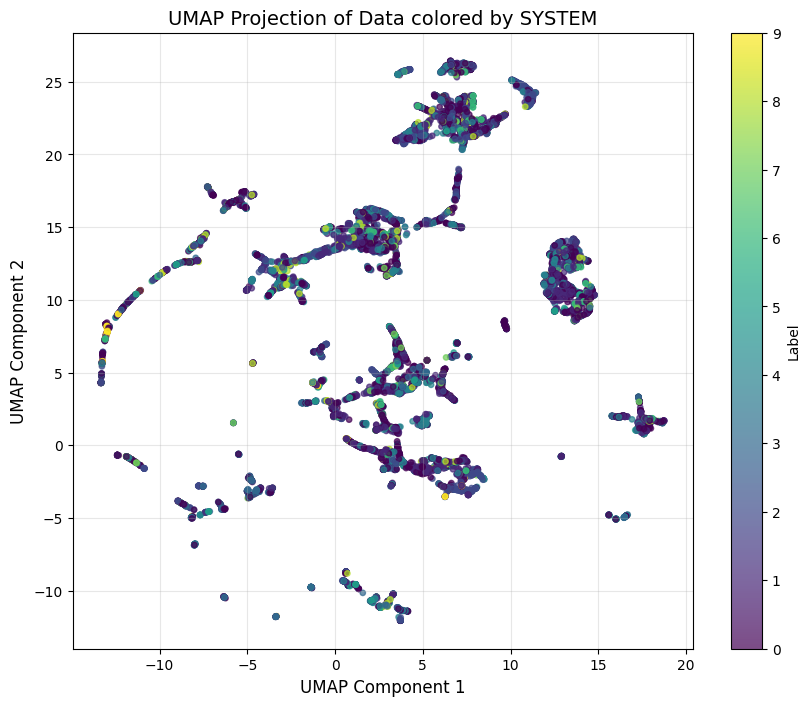

In [27]:
print("\n\n\n==========Sistemi più popolari:==========")
print(dataset_new.groupby('Sistema')['Flotta'].count().nlargest(10))
popular_systems = dataset_new.groupby('Sistema')['Flotta'].count().nlargest(10).index
popular_systems_ds = dataset_new[dataset_new['Sistema'].isin(popular_systems)]
print("\n\n","="*50)
print('Il dataset con i 10 sisitemi più gettonati è lungo ',len(popular_systems_ds), 'record')
print("="*50)
system_map = {desc: i for i, desc in enumerate(popular_systems)}
sistemi_numerici = popular_systems_ds['Sistema'].map(system_map)
print(system_map)

system_embedding = embedding[dataset_new['Sistema'].isin(popular_systems)]
# Visualize the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(system_embedding[:, 0], system_embedding[:, 1], c=sistemi_numerici, s=15, alpha=0.7)
plt.title('UMAP Projection of Data colored by SYSTEM', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.colorbar(label='Label')
plt.grid(True, alpha=0.3)
plt.show()

Epoch 1, Test Accuracy: 0.2445
Epoch 11, Test Accuracy: 0.3913
Epoch 21, Test Accuracy: 0.3922
Epoch 31, Test Accuracy: 0.3909
Epoch 41, Test Accuracy: 0.3979


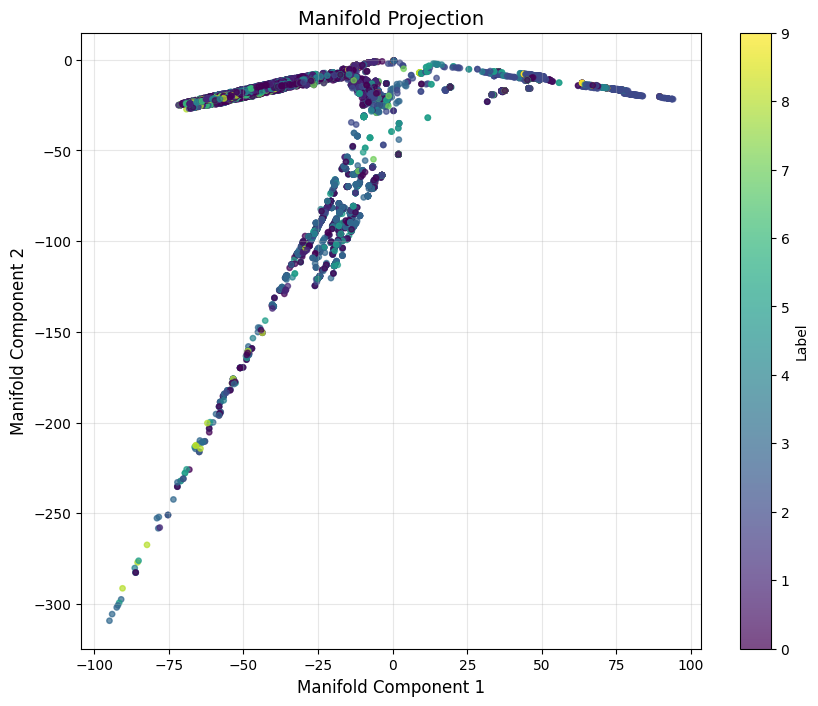

In [28]:
classifier = MLP(
    **{
        'input_dim': X.shape[1],
        'output_dim': 10,
        'layer_norm': True,
        'mode':'OF'})


Y  = sistemi_numerici.values
X_system = X[dataset_new['Sistema'].isin(popular_systems)]
X_train, X_test, Y_train, Y_test = train_test_split(X_system, Y, test_size=0.2, random_state=42)

train_scaler = MinMaxScaler()
X_train_scaled = train_scaler.fit_transform(X_train)
X_test_scaled = train_scaler.transform(X_test)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=0.001)

train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_train_scaled).float(),
    torch.tensor(Y_train).long())
test_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_test_scaled).float(),
    torch.tensor(Y_test).long())

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=False)

for epoch in range(50):
    classifier.train()
    for x, y in train_dataloader:
        optimizer.zero_grad()
        output, _ = classifier(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

    classifier.eval()
    total_correct = 0
    with torch.no_grad():
        for x, y in test_dataloader:
            output, _ = classifier(x)
            predicted = torch.argmax(output, dim=1)
            total_correct += (predicted == y).sum().item()
    accuracy = total_correct / len(test_dataset)
    if epoch % 10 == 0:
        print(f'Epoch {epoch+1}, Test Accuracy: {accuracy:.4f}')


all_X_scaled = train_scaler.transform(X_system)
all_X_scaled = torch.Tensor(all_X_scaled).float()
classifier.eval()
all_preds, manifold = classifier(all_X_scaled)
all_preds = (torch.sigmoid(output.squeeze()) > 0.5).long()
manifold = manifold.numpy()

plt.figure(figsize=(10, 8))
plt.scatter(manifold[:, 0], manifold[:, 1], c=Y.astype(int), s=15, alpha=0.7)
plt.title('Manifold Projection', fontsize=14)
plt.xlabel('Manifold Component 1', fontsize=12)
plt.ylabel('Manifold Component 2', fontsize=12)
plt.colorbar(label='Label')

plt.grid(True, alpha=0.3)
plt.show()



### Component

==========Componenti più popolari:==========
Componente
VEHICLE               3987
MDS                   2379
HVAC_CAB_M8            627
HVAC_CAB_M1            619
T2_1Q2_IR              386
T2_MCB                 221
M3_Porta_gangway_2     201
T7_MCB                 185
M1_9K42                183
M8_9K42                183
Name: Flotta, dtype: int64


Il dataset con i 10 componenti più gettonati è lungo  8971 record
{'VEHICLE': 0, 'MDS': 1, 'HVAC_CAB_M8': 2, 'HVAC_CAB_M1': 3, 'T2_1Q2_IR': 4, 'T2_MCB': 5, 'M3_Porta_gangway_2': 6, 'T7_MCB': 7, 'M1_9K42': 8, 'M8_9K42': 9}


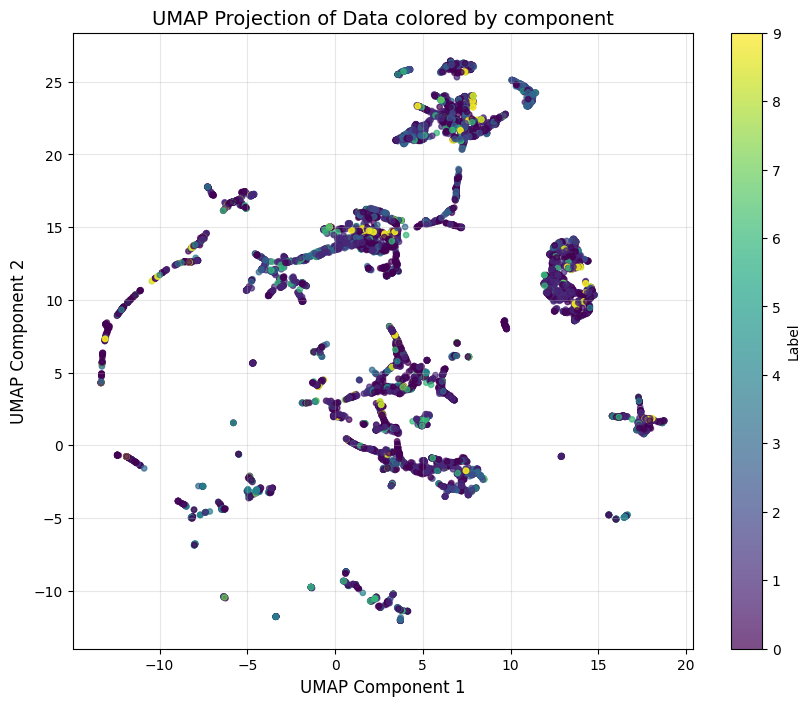

In [30]:
print("==========Componenti più popolari:==========")
print(dataset_new.groupby('Componente').count()['Flotta'].nlargest(10))
popular_components = dataset_new.groupby('Componente')['Flotta'].count().nlargest(10).index
popular_components_ds = dataset_new[dataset_new['Componente'].isin(popular_components)]
print("\n\n","="*50)
print('Il dataset con i 10 componenti più gettonati è lungo ',len(popular_components_ds), 'record')
print("="*50)
component_map = {desc: i for i, desc in enumerate(popular_components)}
componenti_numerici = popular_components_ds['Componente'].map(component_map)
print(component_map)

component_embedding = embedding[dataset_new['Componente'].isin(popular_components)]
# Visualize the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(component_embedding[:, 0], component_embedding[:, 1], c=componenti_numerici, s=15, alpha=0.7)
plt.title('UMAP Projection of Data colored by component', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.colorbar(label='Label')
plt.grid(True, alpha=0.3)
plt.show()

Epoch 1, Test Accuracy: 0.4462
Epoch 11, Test Accuracy: 0.4451
Epoch 21, Test Accuracy: 0.4451
Epoch 31, Test Accuracy: 0.4435
Epoch 41, Test Accuracy: 0.4435


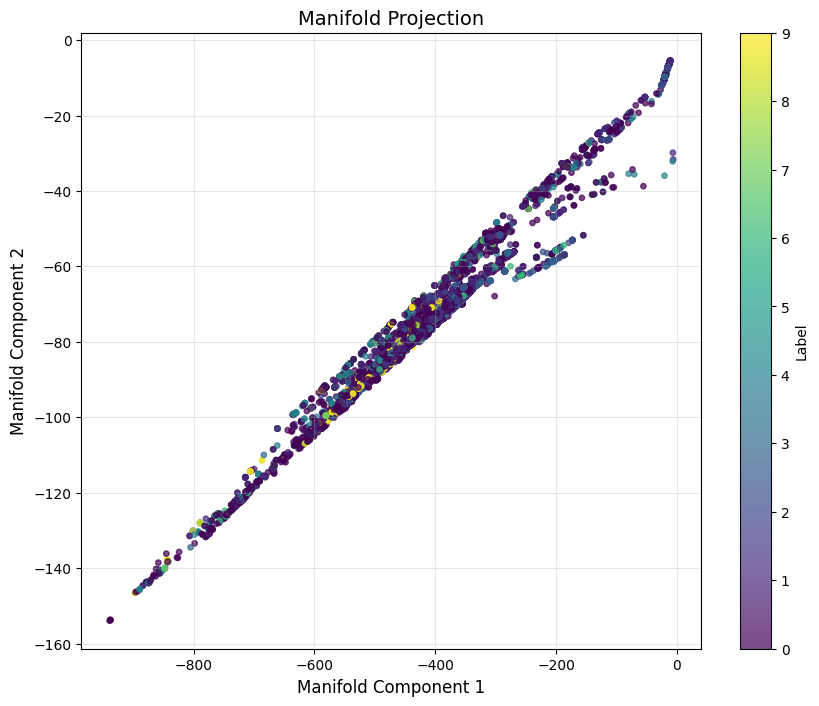

In [31]:
classifier = MLP(
    **{
        'input_dim': X.shape[1],
        'output_dim': 10,
        'layer_norm': True,
        'mode':'OF'})


Y  = componenti_numerici.values
X_comp = X[dataset_new['Componente'].isin(popular_components)]
X_train, X_test, Y_train, Y_test = train_test_split(X_comp, Y, test_size=0.2, random_state=42)

train_scaler = MinMaxScaler()
X_train_scaled = train_scaler.fit_transform(X_train)
X_test_scaled = train_scaler.transform(X_test)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=0.001)

train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_train_scaled).float(),
    torch.tensor(Y_train).long())
test_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_test_scaled).float(),
    torch.tensor(Y_test).long())

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=False)

for epoch in range(50):
    classifier.train()
    for x, y in train_dataloader:
        optimizer.zero_grad()
        output, _ = classifier(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

    classifier.eval()
    total_correct = 0
    with torch.no_grad():
        for x, y in test_dataloader:
            output, _ = classifier(x)
            predicted = torch.argmax(output, dim=1)
            total_correct += (predicted == y).sum().item()
    accuracy = total_correct / len(test_dataset)
    if epoch%10==0:
        print(f'Epoch {epoch+1}, Test Accuracy: {accuracy:.4f}')


all_X_scaled = train_scaler.transform(X_comp)
all_X_scaled = torch.Tensor(all_X_scaled).float()
classifier.eval()
all_preds, manifold = classifier(all_X_scaled)
all_preds = (torch.sigmoid(output.squeeze()) > 0.5).long()
manifold = manifold.numpy()

plt.figure(figsize=(10, 8))
plt.scatter(manifold[:, 0], manifold[:, 1], c=Y.astype(int), s=15, alpha=0.7)
plt.title('Manifold Projection', fontsize=14)
plt.xlabel('Manifold Component 1', fontsize=12)
plt.ylabel('Manifold Component 2', fontsize=12)
plt.colorbar(label='Label')
plt.grid(True, alpha=0.3)
plt.show()

### HMI Status:


ChatGPT says "ERTMS_PiastraSts" might be a label...

Status values are:  [0. 1. 2.]
Status value counts:  ERTMS_PiastraSts
1.0    4575
2.0    4345
0.0    3430
Name: count, dtype: int64


/home/chucho/Projects/Realistic_TCMS_simulation/venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/chucho/Projects/Realistic_TCMS_simulation/venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/chucho/Projects/Realistic_TCMS_simulation/venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


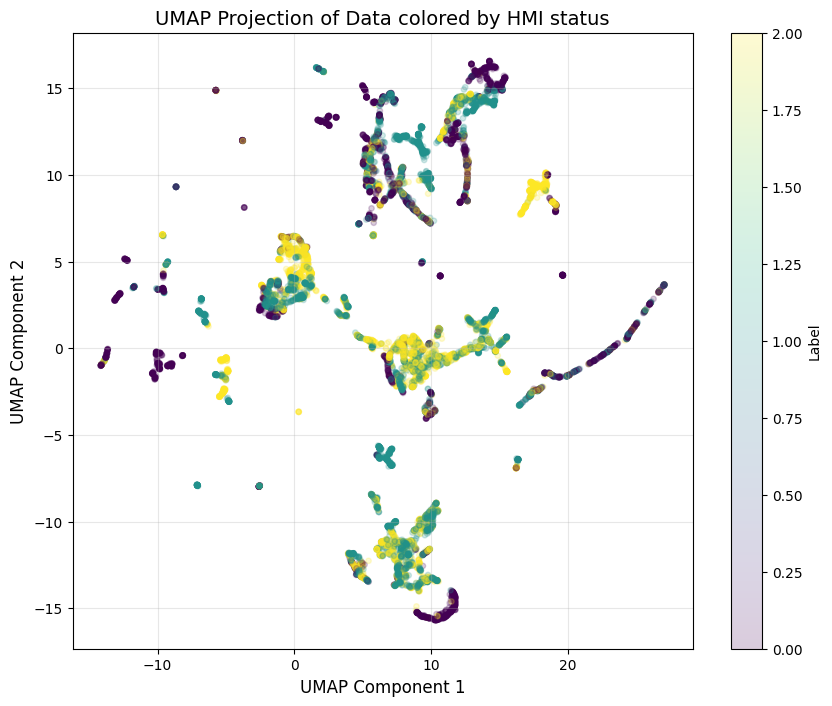

In [73]:
print("Status values are: ", dataset_new["ERTMS_PiastraSts"].unique())
print("Status value counts: ", dataset_new["ERTMS_PiastraSts"].value_counts())
Y_status = dataset_new["ERTMS_PiastraSts"].values
status_ds = dataset_new.drop('ERTMS_PiastraSts', axis=1)

feats_for_status = columns_to_generate.copy()
feats_for_status.remove("ERTMS_PiastraSts")
X_status = dataset_new[feats_for_status].values

status_embedding = reducer.fit_transform(X_status.reshape(X_status.shape[0], -1))


# Visualize the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(status_embedding[:, 0], status_embedding[:, 1], c=Y_status, s=15, alpha=0.2)
plt.title('UMAP Projection of Data colored by HMI status', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.colorbar(label='Label')
plt.grid(True, alpha=0.3)
plt.show()


Epoch 1, Test Accuracy: 0.9547
Epoch 11, Test Accuracy: 0.9704
Epoch 21, Test Accuracy: 0.9688
Epoch 31, Test Accuracy: 0.9725
Epoch 41, Test Accuracy: 0.9713
Accuracy finale:  0.9712550607287449


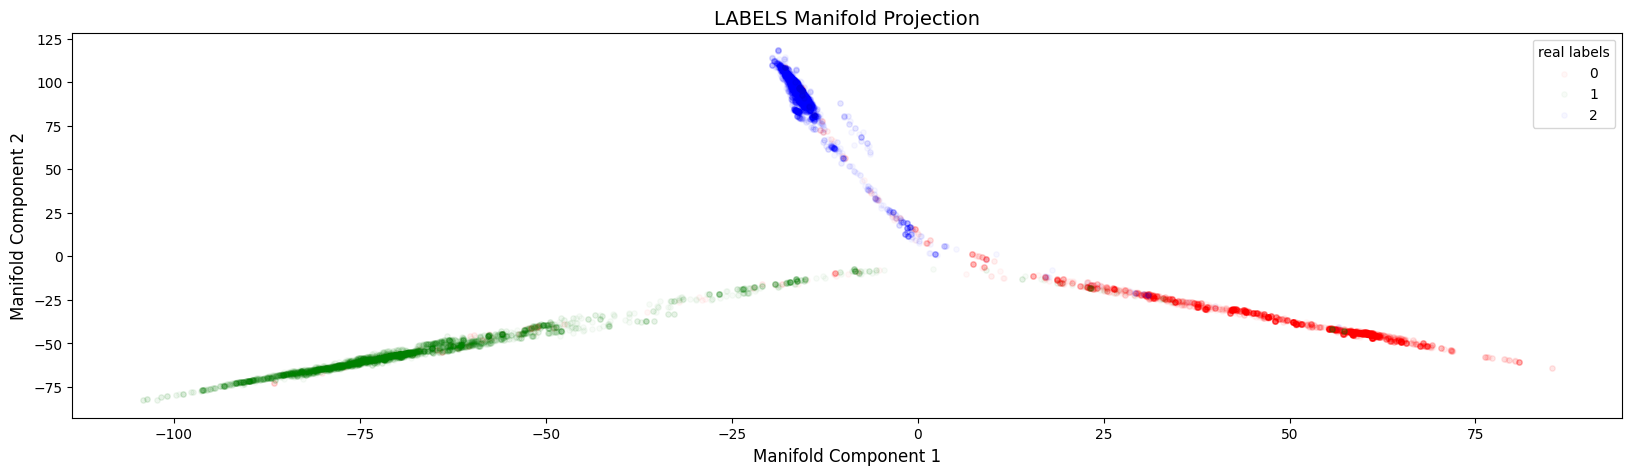

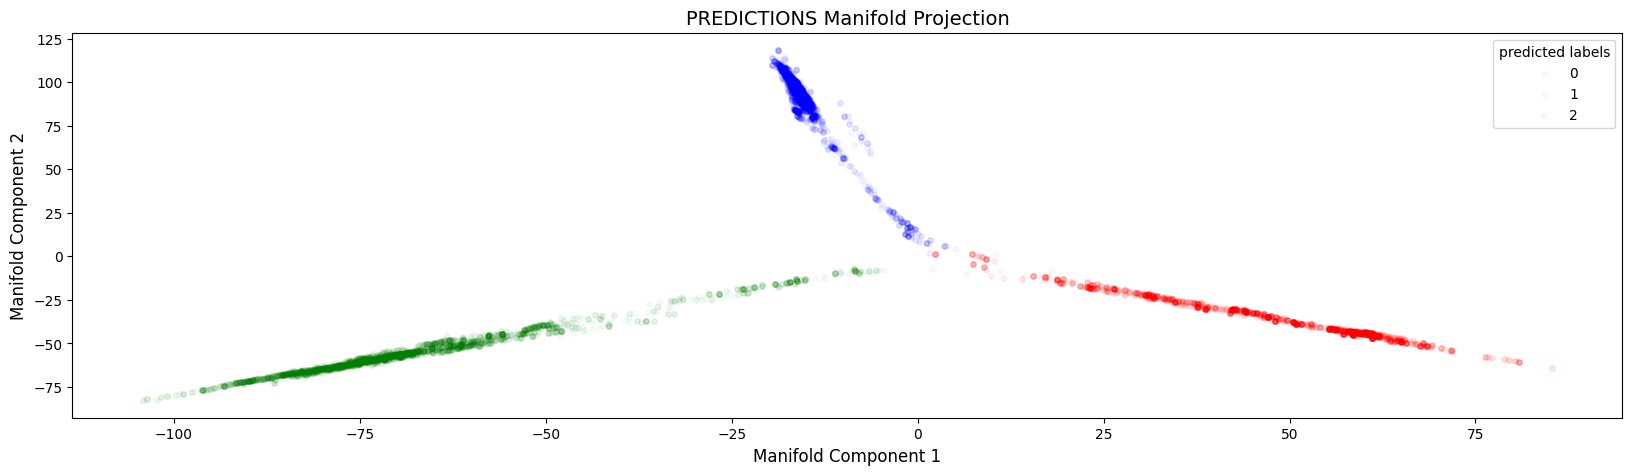

In [103]:
anomaly_classifier = MLP(
    **{
        'input_dim': X_status.shape[1],
        'output_dim': 3,
        'layer_norm': True,
        'mode':'OF'})


Y = Y_status
X_train, X_test, Y_train, Y_test = train_test_split(X_status, Y, test_size=0.2, random_state=42)

train_scaler = MinMaxScaler()
X_train_scaled = train_scaler.fit_transform(X_train)
X_test_scaled = train_scaler.transform(X_test)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(anomaly_classifier.parameters(), lr=0.001)

train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_train_scaled).float(),
    torch.tensor(Y_train).long())
test_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_test_scaled).float(),
    torch.tensor(Y_test).long())

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=False)

for epoch in range(50):
    anomaly_classifier.train()
    for x, y in train_dataloader:
        optimizer.zero_grad()
        output, _ = anomaly_classifier(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

    anomaly_classifier.eval()
    total_correct = 0
    with torch.no_grad():
        for x, y in test_dataloader:
            output, _ = anomaly_classifier(x)
            predicted = torch.argmax(output, dim=1)
            total_correct += (predicted == y).sum().item()
    accuracy = total_correct / len(test_dataset)
    if epoch%10==0:
        print(f'Epoch {epoch+1}, Test Accuracy: {accuracy:.4f}')


all_X_scaled = train_scaler.transform(X_status)
all_X_scaled = torch.Tensor(all_X_scaled).float()
anomaly_classifier.eval()
all_preds, manifold = anomaly_classifier(all_X_scaled)
all_preds = torch.argmax(all_preds, dim=1)
all_correct = (all_preds == Y).sum().item()
all_accuracy = all_correct / len(Y)
print("Accuracy finale: ", all_accuracy)
manifold = manifold.numpy()



# Create a list of unique labels
unique_labels = [int(label) for label in np.unique(Y)]
plt.figure(figsize=(20, 5))

# Create a scatter plot for each label
colors = ['r', 'g', 'b']  # Replace with your desired colors
for label in unique_labels:
    mask = Y == label
    plt.scatter(manifold[mask, 0], manifold[mask, 1], c=colors[label], s=15, alpha=0.03)
# Create the legend
plt.legend(unique_labels, loc='best', title="real labels")
# Set the title, labels, and other plot settings
plt.title('LABELS Manifold Projection', fontsize=14)
plt.xlabel('Manifold Component 1', fontsize=12)
plt.ylabel('Manifold Component 2', fontsize=12)
# Show the plot
plt.show()


plt.figure(figsize=(20, 5))
for label in unique_labels:
    mask = all_preds == label
    plt.scatter(manifold[mask, 0], manifold[mask, 1], c=colors[label], s=15, alpha=0.03)
plt.legend(unique_labels, loc='best', title="predicted labels")
plt.title('PREDICTIONS Manifold Projection', fontsize=14)
plt.xlabel('Manifold Component 1', fontsize=12)
plt.ylabel('Manifold Component 2', fontsize=12)
plt.show()

### Anomalies

WE will statistically define anomalies...
Beware, the following cell overwrites dataset_new with a filtered version.

In [ ]:
dataset = pd.read_csv('dataset.csv')
dataset_new = dataset.copy()
dataset_new['Timestamp'] = pd.to_datetime(dataset_new['Timestamp'], errors='coerce')
# timestamp will be essential
dataset_new = dataset_new.dropna(subset=['Timestamp'])
# repeated signals:
dataset_new = dataset_new.drop_duplicates(subset=['Descrizione', 'Timestamp'])

largest = 5 
anomalous_quantile = 0.4

print('='*20, f'Teniamo soltanto i {largest} componenti e sistemi più popolari','='*20)

top_components = list(dataset_new.groupby(['Componente']).count()['Flotta'].nlargest(largest).index)
top_sistems = list(dataset_new.groupby(['Sistema']).count()['Flotta'].nlargest(largest).index)

print(f"Numero di righe prima del filtraggio: {dataset.shape[0]}")
print(f"Numero di colonne prima della rimozione di colonne vuote: {dataset.shape[1]}")

dataset_new = dataset_new[dataset_new['Componente'].isin(top_components)]
dataset_new = dataset_new[dataset_new['Sistema'].isin(top_sistems)]

dataset_new = dataset_new.dropna(axis=1, how='all')
dataset_new = dataset_new.dropna()
dataset_new.set_index('Timestamp', inplace=True)
print(f"Numero di righe dopo il filtraggio: {dataset_new.shape[0]}")
print(f"Numero di colonne dopo la rimozione di colonne vuote: {dataset_new.shape[1]}")

events_and_occurrences = dataset_new.groupby('Descrizione').count()['Flotta']
print('='*20, 'STATISTICHE DI NUMERO DI OCCORRENZE DI EVENTI (a valle dei filtraggi)','='*20)
print(events_and_occurrences.describe())
event_occurrences = dataset_new.groupby('Descrizione').count().sort_values('Flotta')['Flotta']
plt.figure(figsize=(12, 3))
plt.hist(event_occurrences.values, bins=200, alpha=0.5, color='blue', edgecolor='black')
plt.title('Distribuzione del numero di eventi per numero di occorrenze')
plt.xlabel('Numero di occorrenze')
plt.ylabel('Numero di eventi con quelle occorrenze')
plt.show()

print('='*20, 'PROPOSTA','='*20)
print('più raro è l\'evento, più si può considerare essere un\'anomalia.')
print('Quale è il valore minimo di occorrenze di un evento tale per cui esso NON è un\'anomalia???.')
print('IL 25% degli eventi succede massimo', events_and_occurrences.quantile(.25), ' volte!')
print('IL 50% degli eventi succede massimo', events_and_occurrences.quantile(.50), ' volte!')
print('L 75% degli eventi succede massimo', events_and_occurrences.quantile(.75), ' volte!')

print('Togliamo gli eventi il cui numero di occorrenze è una "coda" della distribuzione:')
all_events = set(dataset_new['Descrizione'].unique())
third_quantile_events = set(event_occurrences[event_occurrences <= events_and_occurrences.quantile(.75)].index)
upper_tail_events = all_events - third_quantile_events
events_to_remove = list(upper_tail_events)
events_to_keep = all_events - set(events_to_remove)
print('toglieremno ',len(upper_tail_events),"  con molte occorrenze.")

dataset_new = dataset_new[dataset_new['Descrizione'].isin(events_to_keep)]
eventi_totali = dataset_new['Descrizione'].nunique()
print(f"siamo rimasti con {len(all_events)}-{len(events_to_remove)}={eventi_totali} eventi")


events_and_occurrences = dataset_new.groupby('Descrizione').count()['Flotta']
print('='*20, 'STATISTICHE DI NUMERO DI OCCORRENZE DI EVENTI (DOPO ULTERIORI filtraggi)','='*20)
print(events_and_occurrences.describe())
event_occurrences = dataset_new.groupby('Descrizione').count().sort_values('Flotta')['Flotta']
plt.figure(figsize=(12, 3))
plt.hist(event_occurrences.values, bins=200, alpha=0.5, color='blue', edgecolor='black')
plt.title('Distribuzione del numero di eventi per numero di occorrenze')
plt.xlabel('Numero di occorrenze')
plt.ylabel('Numero di eventi con quelle occorrenze')
plt.show()

print('='*20, 'PROPOSTA','='*20)
print('più raro è l\'evento, più si può considerare essere un\'anomalia.')
print('Quale è il valore minimo di occorrenze di un evento tale per cui esso NON è un\'anomalia???.')
print('IL 25% degli eventi succede massimo', events_and_occurrences.quantile(.25), ' volte!')
print('IL 50% degli eventi succede massimo', events_and_occurrences.quantile(.50), ' volte!')
print('L 75% degli eventi succede massimo', events_and_occurrences.quantile(.75), ' volte!')


min_occorrences_for_beign_normal = events_and_occurrences.quantile(anomalous_quantile)
print(f'Consideriamo anomalia tutto ciò che succede massimo {min_occorrences_for_beign_normal} volte, corrispondete al quantile {anomalous_quantile}!')

print('='*20, 'Così facendo abbiamo:','='*20)


print(f'nel nostro dataset abbiamo {eventi_totali} TIPI DI EVENTI diversi')
record_totali = len(dataset_new)
print(f'sparsi in un totale di {record_totali} record')

anomalies = event_occurrences[event_occurrences <= min_occorrences_for_beign_normal].index


record_anomalie = len(dataset_new[dataset_new['Descrizione'].isin(anomalies)])
print(f'di cui {record_anomalie} corrispondono ad anomalie')

"""
anomalies_ds = dataset_new.copy()
anomalies_ds['anomaly'] = dataset_new['Descrizione'].isin(anomalies)
anomalies_ds.to_csv('boundary_attacks/anomalies_ds.csv')
"""

In [ ]:
X = dataset_new[columns_to_generate].values
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
# Fit and transform the data
embedding = reducer.fit_transform(X.reshape(X.shape[0], -1))

plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], s=15, alpha=0.7)
plt.title('UMAP Projection', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


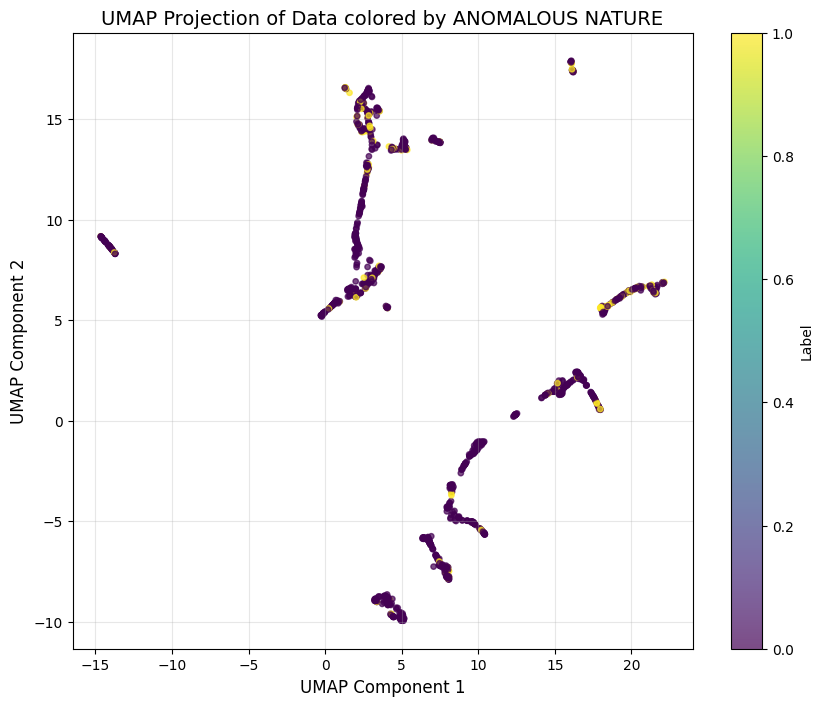

In [28]:
anomalous = dataset_new['Descrizione'].isin(anomalies).values
# Visualize the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], c=anomalous, s=15, alpha=0.7)
plt.title('UMAP Projection of Data colored by ANOMALOUS NATURE', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.colorbar(label='Label')
plt.grid(True, alpha=0.3)
plt.show()

Epoch 1, Test Accuracy: 0.8674
Epoch 11, Test Accuracy: 0.8853
Epoch 21, Test Accuracy: 0.8925
Epoch 31, Test Accuracy: 0.8889
Epoch 41, Test Accuracy: 0.8925


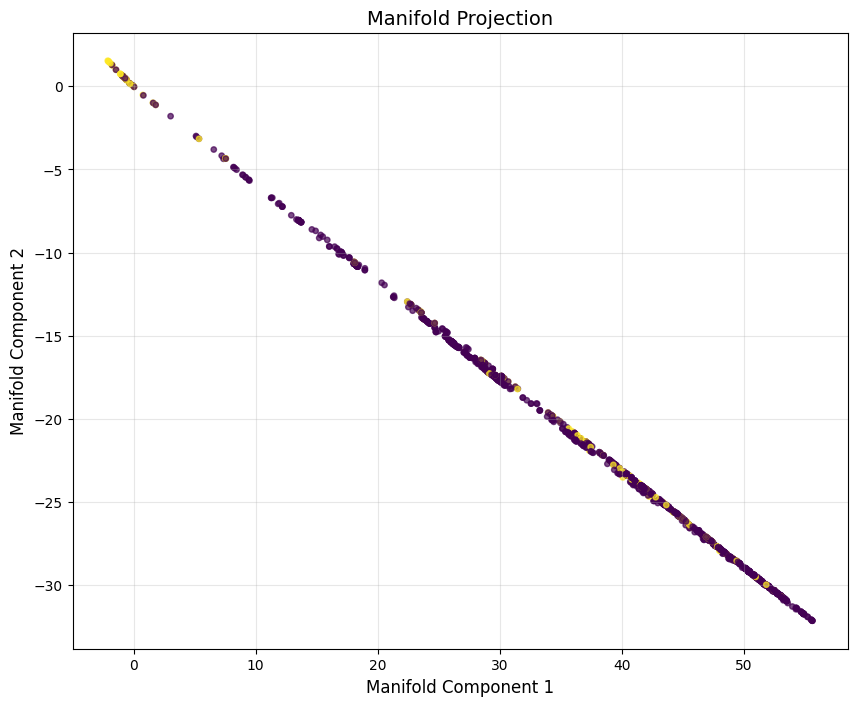

In [ ]:
anomaly_classifier = MLP(
    **{
        'input_dim': X.shape[1],
        'output_dim': 2,
        'layer_norm': True,
        'mode':'OF'})


Y = anomalous = dataset_new['Descrizione'].isin(anomalies).values
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

train_scaler = MinMaxScaler()
X_train_scaled = train_scaler.fit_transform(X_train)
X_test_scaled = train_scaler.transform(X_test)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(anomaly_classifier.parameters(), lr=0.001)

train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_train_scaled).float(),
    torch.tensor(Y_train).long())
test_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_test_scaled).float(),
    torch.tensor(Y_test).long())

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=False)

for epoch in range(50):
    anomaly_classifier.train()
    for x, y in train_dataloader:
        optimizer.zero_grad()
        output, _ = anomaly_classifier(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

    anomaly_classifier.eval()
    total_correct = 0
    with torch.no_grad():
        for x, y in test_dataloader:
            output, _ = anomaly_classifier(x)
            predicted = torch.argmax(output, dim=1)
            total_correct += (predicted == y).sum().item()
    accuracy = total_correct / len(test_dataset)
    if epoch%10==0:
        print(f'Epoch {epoch+1}, Test Accuracy: {accuracy:.4f}')


all_X_scaled = train_scaler.transform(X)
all_X_scaled = torch.Tensor(all_X_scaled).float()
anomaly_classifier.eval()
all_preds, manifold = anomaly_classifier(all_X_scaled)
all_preds = (torch.sigmoid(output.squeeze()) > 0.5).long()
manifold = manifold.numpy()

plt.figure(figsize=(10, 8))
plt.scatter(manifold[:, 0], manifold[:, 1], c=Y.astype(int), s=15, alpha=0.7)
plt.title('Manifold Projection', fontsize=14)
plt.xlabel('Manifold Component 1', fontsize=12)
plt.ylabel('Manifold Component 2', fontsize=12)
plt.colorbar(label='Label')
plt.grid(True, alpha=0.3)
plt.show()



## Conclusion:

unless we fake, we cannot obtain any benefit by doing boundary attacks on these data.

# Rewritting the history.



We need **plausible engineering semantics** that will let us:

* build a **synthetic dataset with meaningful correlations**,
* simulate **normal behaviour**, **physical anomalies**, and **cyberattacks**,
* make **labels** that correspond to interpretable subsystem states.




We are going to group real columns into **physical subsystems** and propose clearer, interpretable names.
We will also invent a **causal story**, which will guide the synthetic generator.



In [104]:
# ============================================================
# UTILS: noise injection and value bounding
# ============================================================

def smooth_noise(scale=1.0):
    return np.random.normal(0, scale)

def bounded(value, min_val, max_val):
    return float(np.clip(value, min_val, max_val))



In [105]:
# ============================================================
# EVENT MANAGEMENT: we are goinf to have three simple events:
# ============================================================

NORMAL = "normal"
ANOMALY = "anomaly"
ATTACK = "attack"

def choose_event(p_normal=0.90, p_anomaly=0.07, p_attack=0.03):
    r = np.random.rand()
    if r < p_attack:
        return ATTACK
    elif r < p_attack + p_anomaly:
        return ANOMALY
    else:
        return NORMAL


In [106]:
# ============================================================
# SIMULATION CLASS: an object that contains the train's state
# ============================================================

class SimState:
    def __init__(self):
        # Train context
        self.duration = 0
        self.speed = 0.0
        self.speed_limit = 120.0
        self.lat = 45.50
        self.lon = 11.20

        # Cab & mode
        self.active_cab = "M1"
        self.driving_mode = 1  # standstill

        # Traction & electrical
        self.line_volt_type = 2   # DC=2, AC=4
        self.line_voltage = 3000.0
        self.line_current = 0.

        self.batt_T = {
            "T2": 29.0,
            "T4": 29.0,
            "T5": 29.0,
            "T7": 29.0,
        }

        # Hydraulic subsystem
        self.brake_press_cylinder_main = {m: 0.0 for m in ["M1","M3","M6","M8"]}
        self.brake_press_cylinder_trailer = {t: 0.0 for t in ["T2","T4","T5","T7"]}
        self.bp = 5.0
        self.mp = 9.0

        # ERTMS / HMI
        self.ertms_status = 1
        self.ac_status = {"T2": 0, "T7": 0}
        self.dc_status = {"T2": 1, "T7": 1}
        self.sil_impact = 2000.0

## First subsystem: **TRAIN STATE & CONTEXT**


This subsystem describes *where the train is, how fast it moves, and how long the operational segment has been active*.
These variables act as **primary drivers** for downstream physical subsystems (traction, electrical load, braking, etc.).

### **1.1 Durata (segment duration)**

**Meaning:** Amount of time (in seconds) since the current operational segment began.

**Role in the causal model:**

* Increases monotonically until the segment ends or a maintenance/reset event occurs.
* Slowly affects battery heating, auxiliary load accumulation, and some counters.

**Correlations:**

* Higher *Durata* → slight ↑ battery temperature, slight ↓ battery voltage (ageing profile).
* Should NOT directly correlate with events/labels unless a reset is tied to a maintenance event.


### **1.2 TrainSpeed_kmh (from `ldvveltreno`)**
**Meaning:** Real speed of the train.
**Correlations:**
* ↑ Speed → ↑ traction current (`HMI_Iline`).
* ↑ Speed → ↓ brake pressures (unless braking).
* Strongly constrained by speed limits.

**Anomalies/Attacks:**
* Fake speed measurement (cyber) produces inconsistencies:
  * high speed with low current,
  * sudden jumps,
  * violation of speed limits.

### **1.3 SpeedLimit_kmh (from `ldvvelimps` or `MDS_LedLimVel`)**
**Meaning:** Current ERTMS speed limit for the block/section.
**Correlations:**
* Normally: `TrainSpeed ≤ SpeedLimit`.
* Abrupt changes reflect block transitions.
* Interaction with ERTMS state (if ERTMS degraded → more restrictive limits).

**Anomalies/Attacks:**
* Limit suddenly drops to 0 or unrealistic values (signal spoofing).
* Tampering allows overspeed (limit artificially raised).

### **1.4 GPS_Lat, GPS_Lon (position)**
**Meaning:** Coarse geographical position.
**Correlations:**
* Must follow a smooth trajectory (bounded derivative).
* Correlates indirectly with speed (distance increments match velocity profile).

**Anomalies/Attacks:**
* Jumps, reversals, impossible speeds → GNSS spoofing.
* Inconsistent with speed or odometry.

In [107]:
train_state = [
    'Durata',
    'ldvveltreno',
    'HMI_Iline',
    'ldvvelimps',
    'MDS_LedLimVel',
    '_GPS_LAT',
    '_GPS_LON']

dataset_new[[col for col in train_state]].describe()

,Durata,ldvveltreno,HMI_Iline,ldvvelimps,MDS_LedLimVel,_GPS_LAT,_GPS_LON
count,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000
mean,515.916194,48.227530,144.853522,145.789069,0.005101,45.516506,11.198882
std,3224.445554,67.191847,352.561588,93.667302,0.071243,0.093436,1.464760
min,1.000000,0.000000,-1166.000000,0.000000,0.000000,45.401500,9.205700
25%,4.000000,0.000000,44.000000,30.000000,0.000000,45.481200,9.532200
50%,11.000000,4.000000,68.000000,150.000000,0.000000,45.487700,11.575300
75%,58.000000,101.000000,106.000000,250.000000,0.000000,45.511400,12.225700
max,98659.000000,251.000000,2178.000000,250.000000,1.000000,45.829600,13.770300


In [108]:
for col in train_state:
    print(f'{col} has {len(dataset_new[col].unique())} unique vals')

Durata has 1237 unique vals
ldvveltreno has 232 unique vals
HMI_Iline has 951 unique vals
ldvvelimps has 41 unique vals
MDS_LedLimVel has 2 unique vals
_GPS_LAT has 1566 unique vals
_GPS_LON has 3261 unique vals


In [109]:
dataset_new['ldvvelimps'].unique()

array([  0., 250.,  30.,  85.,  90., 125., 150., 170., 200., 155., 110.,
        60., 145., 180., 185., 160., 115.,  40.,  75., 140., 165., 135.,
       190.,  95., 220.,  80., 245.,  50., 100., 130., 120.,  55., 235.,
       210.,  45., 215., 105.,  65.,  70., 230., 225.])

In [110]:
dataset_new['MDS_LedLimVel'].unique()

array([0., 1.])

In [111]:
def generate_train_context(state: SimState, event_type):
    # ============================================================
    # SUBSYSTEM 1 — TRAIN STATE & CONTEXT
    # ============================================================

    # Duration always increases
    state.duration += 1

    # Speed dynamics depend on driving mode
    accel_map = {
        1: 0.0,     # standstill
        2: +1.5,    # traction
        4: -0.2,    # coasting
        5: -2.5,    # braking
    }

    accel = accel_map.get(state.driving_mode, 0.0)

    if event_type == ANOMALY and np.random.rand()<0.7:
        accel_map = {
        1: 0.1,     # standstill (crazy train!)
        2: +1.1,    # traction (pedal aint working)
        4: +0.1,    # coasting (outa control!)
        5: -0.5,    # lazy brakes!
    }


    state.speed = bounded(state.speed + accel + smooth_noise(0.5), 0, 250)

    # Speed limit evolves smoothly
    if np.random.rand() < 0.01:
        state.speed_limit = np.random.choice([30, 60, 90, 120, 140, 160, 180])

    # GPS follows motion
    state.lat += smooth_noise(0.0001) + 0.00001 * (state.speed / 100)
    state.lon += smooth_noise(0.0001) + 0.00001 * (state.speed / 100)

    # Cyberattack: GPS spoof
    if event_type == ATTACK and np.random.rand() < 0.3:
        state.lat += np.random.normal(0.05, 0.02)
        state.lon += np.random.normal(0.05, 0.02)

    return {
        "Durata": state.duration,
        "ldvveltreno": state.speed,
        "ldvvelimps": state.speed_limit,
        "_GPS_LAT": state.lat,
        "_GPS_LON": state.lon
    }

## Second subsystem: **CAB & CONTROL SYSTEM STATUS**


This subsystem encodes which cab is driving and which operation mode is active. These variables influence brake/traction and determine “control intent”.
### **2.1 CabActive_M1 / CabActive_M8**
**Meaning:** Active driving cab (front/back).
**Correlations:**
* Mutually exclusive: `CabEnabled_M1 + CabEnabled_M8 = 1`.
* Correlates with direction choice and with the active end for pressures and door commands.
* When switching cab → transient control events may arise.

**Anomalies:**
* Both active or none active → invalid state (cyber attack or TCMS fault).

### **2.2 DrivingMode (from `MDS_StatoMarcia`)**

**Meaning:** Current operating mode:
* **1 = Standstill**,
* **2 = Traction**,
* **4 = Coasting**,
* **5 = Braking** (our dataset uses these codes!).

**Correlation proposal:**
* **Traction (2)** → ↑ `HMI_Iline`, ↑ battery load.
* **Coasting (4)** → near-zero current.
* **Braking (5)** → ↑ brake pressures, ↓ speed.
* **Standstill (1)** → speed 0, both pressures and currents low.

**Anomalies/Attacks:**
* Braking mode with 0 braking pressure.
* Traction mode with 0 current or increasing pressure → spoofed mode commands.

In [13]:
cab_control = [
    'CabEnabled_M1',
    'CabEnabled_M8',
    'MDS_StatoMarcia',
]

dataset_new[[col for col in cab_control]].describe()

,CabEnabled_M1,CabEnabled_M8,MDS_StatoMarcia
count,12350.000000,12350.00000,12350.000000
mean,0.442024,0.43587,1.326154
std,0.496648,0.49589,0.901149
min,0.000000,0.00000,1.000000
25%,0.000000,0.00000,1.000000
50%,0.000000,0.00000,1.000000
75%,1.000000,1.00000,1.000000
max,1.000000,1.00000,5.000000


In [14]:
for col in cab_control:
    print(f'{col} has {len(dataset_new[col].unique())} unique vals')

CabEnabled_M1 has 2 unique vals
CabEnabled_M8 has 2 unique vals
MDS_StatoMarcia has 4 unique vals


In [15]:
print(f'unique vals for CabEnabled_M1: {dataset_new['CabEnabled_M1'].unique()}')
print(f'unique vals for CabEnabled_M8: {dataset_new['CabEnabled_M8'].unique()}')
print(f'unique vals for MDS_StatoMarcia: {dataset_new['MDS_StatoMarcia'].unique()}')

unique vals for CabEnabled_M1: [0. 1.]
unique vals for CabEnabled_M8: [0. 1.]
unique vals for MDS_StatoMarcia: [4. 1. 2. 5.]


In [112]:
def generate_cab_control(state: SimState, event_type):
    # ============================================================
    # SUBSYSTEM 2 — CAB & CONTROL
    # ============================================================

    # Occasional cab switch (starting, finishing trip or trip-segment)
    if np.random.rand() < 0.001:
        state.active_cab = "M8" if state.active_cab == "M1" else "M1"

    if event_type == ANOMALY and np.random.rand() < 0.8:
        # anomalous evolution of driving mode evolves with speed
        if state.speed < 10:
            state.driving_mode = 1  # standstill
        elif state.speed < 40:
            state.driving_mode = 2  # traction
        else:
            state.driving_mode = np.random.choice([2,4,5], p=[0.1,0.6,0.3])
    else:
        # correct evolution of driving mode evolves with speed
        if state.speed < 1:
            state.driving_mode = 1  # standstill
        elif state.speed < 20:
            state.driving_mode = 2  # traction
        else:
            state.driving_mode = np.random.choice([2,4,5], p=[0.4,0.3,0.3])

    # Cyberattack: wrong mode injected
    if event_type == ATTACK and np.random.rand() < 0.2:
        state.driving_mode = np.random.choice([1,2,4,5])

    return {
        "CabEnabled_M1": 1 if state.active_cab == "M1" else 0,
        "CabEnabled_M8": 1 if state.active_cab == "M8" else 0,
        "MDS_StatoMarcia": state.driving_mode
    }

## Third subsystem **TRACTION & ELECTRICAL SYSTEMS**

The traction and electrical subsystem describes how the train draws energy from the external power supply (overhead catenary), distributes it to traction equipment, and manages its onboard low-voltage electrical network (auxiliaries, batteries, compressors, HVAC, etc.).
This subsystem is one of the most “physics-constrained”: its signals must be inter-correlated according to simple electromechanical rules.
This is extremely useful for our synthetic dataset, because it naturally imposes strong, interpretable correlations between variables.
It is also a rich source of anomalies (electrical faults, pantograph issues, wrong LineVoltType, spoofed readings, overcurrent attacks, etc.).

*(Highly physically coupled subsystem: voltage ↔ current ↔ traction effort ↔ auxiliary load)*

We group signals into four functional areas:

1. **External energy supply** (Line voltage & supply type)
2. **Traction current and load indicators**
3. **Battery subsystem (multiple coaches)**
4. **Auxiliary current counters and reset logic**

Every part has internal constraints **and** cross-correlations with train speed, driving mode, and braking states (from other subsystems).
We explicitly model these below.

### **3.1. External Supply Voltage: `HMI_Vline`**

This is the instantaneous voltage measured at the pantograph. (The thing on top of the train that touches the catenary and allows the train to draw electricity. The catenary is the overhead wire that provides electrical power to trains.)
It depends on which power system the train is operating under:

* **DC network** → nominal approx. **3000 V** (dataset uses values around 2700–3500 V)
* **AC network** → RMS approx. **25,000 V** (dataset shows values up to ~27 kV)

This is the most important “anchor feature” for the electrical part.

#### **Correlations with LineVoltType**

Our dataset encodes supply type as:

* `LineVoltType = 2` → **DC**
* `LineVoltType = 4` → **AC**

Thus, a simple causal rule could be:

```python
if LineVoltType == 2: HMI_Vline ≈ 3000 V ± noise
if LineVoltType == 4: HMI_Vline ≈ 25000 V ± noise
```

This alone would create a strong, interpretable cluster structure.


#### **Correlations with traction behaviour**

In DC mode, under heavy traction load, **voltage sag** is expected: A voltage sag is a short-duration drop in the voltage level of an electrical power supply, typically lasting from a few milliseconds to a few seconds, where voltage falls to about 10–90% of its nominal value.

* High current → Slight drop in HMI_Vline
* Coasting → Stable voltage
* Regenerative braking → Small voltage increases possible (if allowed)


In AC mode this effect is much smaller and mostly filtered. This gives us clear physical dependencies:

```python
HMI_Vline = V_nominal(LineVoltType) - k * HMI_Iline + noise
```

This relationship creates a very easy anomaly generator:

* “Voltage too high for the drawn current”
* “Voltage too low while coasting”
* “Voltage inconsistent with LineVoltType”


#### **Anomalies to simulate**

* Pantograph misalignment → sudden drop to zero or oscillating readings
* Sensor spoofing → voltage not matching current or LineVoltType
* Wrong supply type injected (attacker: fake AC while the train is on DC)


### **3.2. LineCurrent_A: `HMI_Iline`**

This is the traction current drawn from the catenary. 
It is directly proportional to traction effort (accelerating the train) and correlates strongly with speed and mode.

#### **Role in cross-system causality**

Line current depends on:

1. **DrivingMode**

   * `Traction` → high current
   * `Coasting` → near zero
   * `Braking` → zero or small negative (if regenerative exists)
   * `Standstill` → zero (plus auxiliaries if the model includes them through current counters) (Auxiliary load is the electrical power consumed by all onboard systems other than traction.)

2. **TrainSpeed_kmh**

   * At low speed, more current is needed for the same tractive effort
   * At high speed (AC motors): current demand can drop slightly for constant speed

3. **Supply voltage (HMI_Vline)**

   * For a given traction power, current is inversely proportional to voltage
   * Thus we have the physical relation:

     ```python
     traction_power ≈ HMI_Iline * HMI_Vline
     ```

This is an invaluable correlation for anomaly detection.


#### **Typical synthetic dynamics**

We can model current with:

```python
if DrivingMode == traction:
    HMI_Iline = f(speed, train_mass, voltage) + noise
elif DrivingMode == coasting:
    HMI_Iline ≈ 0 + small_noise
elif DrivingMode == braking:
    HMI_Iline ≈ 0 or negative (if regen allowed)
```

This produces realistic clusters and time profiles.


#### **Anomalies to simulate**

* **Traction mode but zero current** → power converter failure or spoofed command
* **High current at standstill** → short-circuit or sensor fault
* **High speed with zero current** → spoofed speed or spoofed current
* **Unphysically large spikes** → tampered current sensor

### **3.3. BatteryVoltage_ for Each Coach** (`HMI_VBatt_T2`, `HMI_VBatt_T4`, `HMI_VBatt_T5`, `HMI_VBatt_T7`)


Each coach has its own low-voltage (24–29 V) subsystem fed by the main converter and backup battery.
These voltages:

* remain almost constant,
* vary slightly depending on auxiliary load (HVAC, doors, compressors),
* slowly degrade with time (or with Durata in a segment).

**Expected correlations**
1. **All battery voltages are cross-correlated**
   Since they are fed from the same DC/DC conversion stage.

2. **Voltage decreases with high auxiliary load**
   E.g., HVAC start → small dip (0.1–0.3 V).

3. **Voltage slightly increases at high catenary voltage**
   (especially on DC supplies)

4. **Compartment-to-compartment differences are small**
   If `V_Batt_T2 = 29.1` V, then T4/T5/T7 will be in the same region ±(0.1–0.3).

Thus:

```python
Vbatt_compartment = V_base + shared_noise + small_independent_noise
```
Battery subsystem may be  valuable for anomaly detection because the natural variance is small, battery signals provide some of the clearest signatures of:
* **electrical faults** (charging converter failure)
* **local subsystem faults** (one coach shows abnormal voltage)
* **sensor tampering** (one coach shows inconsistent readings)

**Anomalies to simulate**

* One coach suddenly drops to 23 V while others remain around 29 V → local battery failure
* All voltages collapsed simultaneously → DC/DC converter fault
* Voltage increases beyond nominal (30+ V) → sensor spoof
* Random jumps → cyber manipulation of sensor channel

### **3.4. Auxiliary Current Reset Counters (`HMI_Irsts_T2`, `HMI_Irsts_T7`)**

These are small integer counters tracking “auxiliary current reset events.”
They typically count resets in auxiliary circuits of compartments (T2, T7).
Reset happens when:

* the train changes active cab
* a technician performs a manual action
* a local subsystem trips or reinitializes
* a fault is cleared

The expected behaviour of the counter is:

* it increments gradually as auxiliary subsystems accumulate load
* it resets to zero when maintenance or automatic protective logic resets the circuit
* it evolves independently from traction current, but slightly correlates with Durata (more time → more auxiliary load/events)

Possible **Correlations**

* Should stay **low-frequency and low-amplitude**.
* Should not decrease unless a reset occurs.
* Rare jumps indicate subsystem reactivation or a fault.

Because the counters follow a very predictable pattern, they are extremely sensitive to cyber-tampering or unexpected resets.

**Anomalies to simulate**

* Counter goes backwards (illegal unless reset event).
* Frequent resets without cab switching → suspicious.
* Reset while the train is in motion at speed → unlikely (flag as anomaly).
* Counter saturates too fast → auxiliary overload.

For the sake of a summary, here is the full causal chain in a compact form for subsystem 3:

```
LineVoltType ──► sets expected HMI_Vline range
                     │
                     ▼
            HMI_Vline combined with DrivingMode and TrainSpeed   ──► determines HMI_Iline
                     │
                     ▼
           HMI_Vline slight influence on battery charging levels
                     │
                     ▼
           BatteryVoltage_* cross-correlate via shared converter
                     │
                     ▼
            Auxiliary load influences battery voltage & resets
```

And the whole subsystem is tightly coupled with the control subsystem (Subsystem 2) and state subsystem (Subsystem 1).

In [114]:
traction_control = [
    'HMI_Vline',
    'LineVoltType',
    'HMI_VBatt_T2', 'HMI_VBatt_T4', 'HMI_VBatt_T5', 'HMI_VBatt_T7',
    'HMI_Irsts_T2', 'HMI_Irsts_T7']

dataset_new[[col for col in traction_control]].describe()

,HMI_Vline,LineVoltType,HMI_VBatt_T2,HMI_VBatt_T4,HMI_VBatt_T5,HMI_VBatt_T7,HMI_Irsts_T2,HMI_Irsts_T7
count,12350.000000,12350.00000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000
mean,4192.141296,2.08081,28.318413,28.500445,28.560826,28.389579,0.474332,0.441215
std,4512.930360,0.39383,1.892333,1.827630,1.823837,1.792796,0.501303,0.496552
min,0.000000,2.00000,20.700000,21.200000,21.300000,21.300000,0.000000,0.000000
25%,3458.000000,2.00000,28.900000,29.100000,29.200000,29.000000,0.000000,0.000000
50%,3534.000000,2.00000,29.000000,29.200000,29.300000,29.100000,0.000000,0.000000
75%,3615.000000,2.00000,29.100000,29.300000,29.300000,29.200000,1.000000,1.000000
max,27157.000000,4.00000,29.300000,29.400000,29.500000,29.400000,2.000000,1.000000


In [115]:
for col in traction_control:
    print(f'{col} has {len(dataset_new[col].unique())} unique vals')

HMI_Vline has 917 unique vals
LineVoltType has 2 unique vals
HMI_VBatt_T2 has 75 unique vals
HMI_VBatt_T4 has 71 unique vals
HMI_VBatt_T5 has 75 unique vals
HMI_VBatt_T7 has 76 unique vals
HMI_Irsts_T2 has 3 unique vals
HMI_Irsts_T7 has 2 unique vals


In [19]:
print(f'unique vals for LineVoltType: {dataset_new['LineVoltType'].unique()}')
print(f'unique vals for HMI_Irsts_T2: {dataset_new['HMI_Irsts_T2'].unique()}')
print(f'unique vals for HMI_Irsts_T7: {dataset_new['HMI_Irsts_T7'].unique()}')
print(f'unique vals for HMI_VBatt_T4: {dataset_new['HMI_VBatt_T4'].unique()}')

unique vals for LineVoltType: [2. 4.]
unique vals for HMI_Irsts_T2: [0. 1. 2.]
unique vals for HMI_Irsts_T7: [1. 0.]
unique vals for HMI_VBatt_T4: [29.2 29.  28.9 28.8 28.7 23.4 23.5 29.1 28.2 23.3 23.2 23.6 23.8 24.2
 29.3 24.  24.1 28.6 28.5 28.3 28.1 28.  27.7 27.5 23.1 24.3 24.4 24.5
 24.8 28.4 27.8 27.6 27.4 27.2 27.3 27.1 26.9 22.5 22.3 23.  27.9 25.8
 26.7 25.1 23.7 23.9 27.  25.7 25.6 22.1 22.2 22.4 22.6 22.7 22.8 24.6
 25.2 29.4 26.8 24.9 25.  26.5 26.2 24.7 26.6 26.1 21.2 21.3 21.4 21.5
 22. ]


In [116]:
def generate_traction(state: SimState, event_type):
    # ============================================================
    # SUBSYSTEM 3 — TRACTION & ELECTRICAL
    # ============================================================

    # Line voltage depends on AC/DC
    if state.line_volt_type == 2:   # DC
        state.line_voltage = 3000 + smooth_noise(200)
    else:
        state.line_voltage = 25000 + smooth_noise(1000)

    # Line current follows speed + mode
    desired_curr = 0
    if state.driving_mode == 2:   # traction
        desired_curr = 150 + 2 * state.speed
    elif state.driving_mode == 5: # braking
        desired_curr = -50 - state.speed
    else:
        desired_curr = 0

    state.line_current = desired_curr + smooth_noise(10)

    if event_type == ANOMALY and np.random.rand() < 0.8:
        state.line_current = desired_curr + smooth_noise(100)

    # Battery drift
    for k in state.batt_T.keys():
        state.batt_T[k] = bounded(state.batt_T[k] + smooth_noise(0.02), 21, 29.5)

    # Cyberattack: spoof voltage
    if event_type == ATTACK and np.random.rand() < 0.3:
        state.line_voltage *= np.random.uniform(0.5, 1.5)

    return {
        "HMI_Vline": state.line_voltage,
        "LineVoltType": state.line_volt_type,
        "HMI_Iline": state.line_current,
        **{f"HMI_VBatt_{k}": state.batt_T[k] for k in state.batt_T.keys()},
        "HMI_Irsts_T2": 0,
        "HMI_Irsts_T7": 0,
    }


## Fourth subsystem: **HYDRAULIC / BRAKE SYSTEM**




We have many `usB1` and `usB2` pressures for different modules (M1, M3, etc.).

In many European rolling-stock pneumatic brake architectures:
- B1 = Brake Chain 1 (first brake pipe / first control chain)
- B2 = Brake Chain 2 (redundant second brake pipe / second control chain)
The prefix us simply means “unit status” or “unit sensor”, depending on manufacturer naming conventions.
So:
- usB1 = sensor/status signal for Brake Chain 1
- usB2 = sensor/status signal for Brake Chain 2

Each chain provides values such as:
- CilPres (cylinder pressure)
- BpPres (brake pipe pressure)
- MpPres (main reservoir pressure)



We see columns like:
- usB1BCilPres_M1 → brake cylinder pressure of motor car M1 on brake chain B1
- usB2BCilPres_M1 → same actuator, but reported on brake chain B2
- usBpPres → brake pipe pressure
- usMpPres → main reservoir pressure

This subsystem models the pneumatic braking system across multiple modules (M1, M3, M6, M8, T2, T4, T5, T7).

    

### **4.1 BrakeCylinderPressures for Main Cars (M1/M3/M6/M8)**

**Meaning:** Brake cylinder pressures for motor cars.
The brake cylinder is the actuator that actually applies the brakes
- 0 bar → no braking
- 1–3 bar → normal to strong braking
- 3+ bar → emergency braking

**Correlations:**

* **Braking mode (5)** → pressures rise (0 → ~2.6 bar).
* **Traction or Coasting** → pressures ≈0.
* Smooth propagation: M1 and M8 respond fastest, others slightly lag.

**Anomalies:**

* One module not braking while others do → actuator fault.
* Pressure spikes while in traction → pneumatic leak or sensor misread.



### **4.2 BrakeCylinderPressures for Trailer Cars (T2/T4/T5/T7)**

**Meaning:** Trailer braking pressures.

**Correlations:**

* Should mirror main car pressures with slight delay.
* Lower mean pressure under identical braking command.

**Anomalies:**

* Trailer pressures zero while main pressures rise → brake isolation or cyber attack.



### **4.3 Pneumatic Pressures (usBpPres, usMpPres)**

**Meaning:**

* **Bp** = brake pipe pressure.
* **Mp** = main reservoir pressure.

The brake pipe is the long air pipe running along the entire train, connecting all cars.
It is the command channel of the braking system, every car. It’s global, not local.
If the brake pipe pressure drops, all cars begin braking:
- 5 bar → Release brakes (train free to move)
- Drop to 4 bar → Apply brakes
- Drop further → Stronger braking
- 0 bar → Emergency brake

Main Reservoir (MR / MP): A high-pressure air tank on each locomotive (or motor car).
This is the source of compressed air for everything:Refilling the brake pipe, Refilling brake cylinders after release, Operating valves, and, sometimes, powering doors or auxiliary systems. 
- 8–10 bar normal
- Under ~7 bar → potentially problematic (compressor struggling)

The main reservoir feeds the brake pipe. If MR pressure drops too low, the train might not be able to release brakes or refill the system.


**Correlations:**

* Braking → ↓ brake pipe pressure, ↓ main pipe pressure.
* Should remain within design constraints (Bp ~5 bar, Mp ~9 bar).

**Anomalies:**

* Rapid depression of Mp → leak.
* Misalignment between Mp/Bp → valve fault or spoof.

In [117]:
hydraulic = [
    'usB1BCilPres_M1', 
    'usB1BCilPres_M3', 
    'usB1BCilPres_M6', 
    'usB1BCilPres_M8',
    'usB1BCilPres_T2', 
    'usB1BCilPres_T4', 
    'usB1BCilPres_T5', 
    'usB1BCilPres_T7', 
    'usB2BCilPres_M1', 
    'usB2BCilPres_M3',
    'usB2BCilPres_M6', 
    'usB2BCilPres_M8', 
    'usB2BCilPres_T2', 
    'usB2BCilPres_T4', 
    'usB2BCilPres_T5', 
    'usB2BCilPres_T7',
    'usBpPres', 'usMpPres'
]

dataset_new[[col for col in hydraulic]].describe()

,usB1BCilPres_M1,usB1BCilPres_M3,usB1BCilPres_M6,usB1BCilPres_M8,usB1BCilPres_T2,usB1BCilPres_T4,usB1BCilPres_T5,usB1BCilPres_T7,usB2BCilPres_M1,usB2BCilPres_M3,usB2BCilPres_M6,usB2BCilPres_M8,usB2BCilPres_T2,usB2BCilPres_T4,usB2BCilPres_T5,usB2BCilPres_T7,usBpPres,usMpPres
count,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000
mean,0.959422,0.937780,0.966804,0.917172,0.841155,0.793266,0.729365,0.941257,0.951897,0.931815,0.965690,0.914646,0.831730,0.791872,0.729147,0.947565,3.362164,8.342187
std,1.178949,1.164162,1.200429,1.147987,1.061107,0.963450,0.934049,1.158200,1.176764,1.155364,1.197785,1.147530,1.054384,0.961198,0.932743,1.161386,2.142696,1.860113
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000,0.290000,8.480000
50%,0.040000,0.010000,0.010000,0.020000,0.020000,0.010000,0.000000,0.020000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.000000,0.020000,4.810000,8.810000
75%,2.620000,2.580000,2.640000,2.520000,2.400000,2.110000,2.050000,2.540000,2.610000,2.560000,2.640000,2.540000,2.380000,2.110000,2.040000,2.550000,4.940000,9.140000
max,2.830000,2.730000,2.840000,2.960000,2.690000,2.400000,2.490000,2.860000,2.820000,2.710000,2.830000,2.800000,2.630000,2.460000,2.430000,2.860000,5.090000,9.710000


In [118]:
def generate_hydraulics(state: SimState, event_type):
    # ============================================================
    # SUBSYSTEM 4 — HYDRAULIC / BRAKES
    # ============================================================
    if state.driving_mode == 5:  # braking
        base_pressures_cylinders = 2.5
    else:
        base_pressures_cylinders = 0.0

    for k in state.brake_press_cylinder_main.keys():
        state.brake_press_cylinder_main[k] = bounded(base_pressures_cylinders + smooth_noise(0.2), 0, 3)

    for k in state.brake_press_cylinder_trailer.keys():
        state.brake_press_cylinder_trailer[k] = bounded(base_pressures_cylinders + smooth_noise(0.3), 0, 3)

    # Pneumatic supply
    state.bp = bounded(5 + smooth_noise(0.3), 0, 5)
    state.mp = bounded(9 + smooth_noise(0.3), 7, 10)

    # Anomaly: one module not braking
    if event_type == ANOMALY and np.random.rand() < 0.8:
        bad_mod = np.random.choice(list(state.brake_press_cylinder_main.keys()))
        state.brake_press_cylinder_main[bad_mod] = 0.0
        state.brake_press_cylinder_trailer[bad_mod] = bounded(0.0 + smooth_noise(0.3), 0.0, 0.5)

    # ATTACK: pneumatic supply hacking!
    if event_type == ATTACK and np.random.rand() < 0.5:
        state.bp = bounded(2 + smooth_noise(0.3), 0, 5)
        state.mp = bounded(5 + smooth_noise(0.3), 7, 10)

    return {
        **{f"usB1BCilPres_{k}": state.brake_press_cylinder_main[k] for k in state.brake_press_cylinder_main.keys()},
        **{f"usB1BCilPres_{k}": state.brake_press_cylinder_main[k] for k in state.brake_press_cylinder_main.keys()},
        **{f"usB2BCilPres_{k}": state.brake_press_cylinder_main[k] for k in state.brake_press_cylinder_main.keys()},
        **{f"usB1BCilPres_{k}": state.brake_press_cylinder_trailer[k] for k in state.brake_press_cylinder_trailer.keys()},
        **{f"usB2BCilPres_{k}": state.brake_press_cylinder_trailer[k] for k in state.brake_press_cylinder_trailer.keys()},
        "usBpPres": state.bp,
        "usMpPres": state.mp
    }

## Fift subsystem: **ERTMS / HMI / STATUS VARIABLES**

Digital subsystem representing safety logic, HMI commands, and AC/DC point statuses.

### **5.1 ERTMS_Status (ERTMS_PiastraSts)**

**Meaning:** Overall state of ERTMS onboard computer (Normal / Degraded / Fault).

**Correlations:**

* In degraded mode → stricter speed supervision (lower `SpeedLimit`).
* May trigger emergency braking if mismatched with GPS or speed.

**Anomalies:**

* ERTMS reports "normal" while other subsystems detect inconsistencies → spoofing.

### **5.2 HMI_AC/DC_PointStatuses (HMI_ACPntSts_*, HMI_DCPntSts_*)**

**Meaning:** Status of AC/DC distribution points for each coach.

**Correlations:**

* Should match battery voltages and line voltage availability.
* AC statuses active only under AC mode, etc.

**Anomalies:**

* Point status says OFF but battery is fully energized → manipulation.
* AC Point stays ON in a DC-only segment.


### **5.3 LineVoltType**

**Meaning:** Type of supply line (2 = DC, 4 = AC in your dataset).

**Correlations:**

* Determines expected voltage ranges in `HMI_Vline`.
* Influences which AC/DC power points should be active.

**Anomalies:**

* LineVoltType = DC but voltage ~25kV → spoofed voltage sensor.
* Frequent toggles → cyber or hardware instability.


### **5.4 SIL_ImpactValue (HMI_impSIL)**

**Meaning:** Internal diagnostic counter (Safety Integrity Level impact).

**Correlations:**

* Slowly trending upward (aging, accumulated diagnostics).
* Reset only during maintenance.

**Anomalies:**

* Abrupt spikes → electronic fault or memory corruption.
* Sudden reset without maintenance → tampering.

In [119]:
ertms = [
    'ERTMS_PiastraSts',
    'HMI_ACPntSts_T2', 'HMI_ACPntSts_T7', 'HMI_DCPntSts_T2', 'HMI_DCPntSts_T7',
    'LineVoltType', 
    'HMI_impSIL'
]

dataset_new[[col for col in ertms]].describe()

,ERTMS_PiastraSts,HMI_ACPntSts_T2,HMI_ACPntSts_T7,HMI_DCPntSts_T2,HMI_DCPntSts_T7,LineVoltType,HMI_impSIL
count,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.00000,12350.000000
mean,1.074089,0.021457,0.015951,0.565425,0.520081,2.08081,2015.368421
std,0.790010,0.144910,0.125293,0.516834,0.517452,0.39383,348.438330
min,0.000000,0.000000,0.000000,0.000000,0.000000,2.00000,1200.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,2.00000,1800.000000
50%,1.000000,0.000000,0.000000,1.000000,1.000000,2.00000,2000.000000
75%,2.000000,0.000000,0.000000,1.000000,1.000000,2.00000,2400.000000
max,2.000000,1.000000,1.000000,2.000000,2.000000,4.00000,2400.000000


In [120]:
for col in ertms:
    print(f'{col} has {len(dataset_new[col].unique())} unique vals')
    print(f'{col} unique vals: {dataset_new[col].unique()}')

ERTMS_PiastraSts has 3 unique vals
ERTMS_PiastraSts unique vals: [0. 1. 2.]
HMI_ACPntSts_T2 has 2 unique vals
HMI_ACPntSts_T2 unique vals: [0. 1.]
HMI_ACPntSts_T7 has 2 unique vals
HMI_ACPntSts_T7 unique vals: [0. 1.]
HMI_DCPntSts_T2 has 3 unique vals
HMI_DCPntSts_T2 unique vals: [1. 0. 2.]
HMI_DCPntSts_T7 has 3 unique vals
HMI_DCPntSts_T7 unique vals: [1. 0. 2.]
LineVoltType has 2 unique vals
LineVoltType unique vals: [2. 4.]
HMI_impSIL has 6 unique vals
HMI_impSIL unique vals: [1800. 1600. 1200. 2400. 2000. 2200.]


In [121]:
dataset_new['ERTMS_PiastraSts'].value_counts()

ERTMS_PiastraSts
1.0    4575
2.0    4345
0.0    3430
Name: count, dtype: int64

What a heck?! the train is one third of the time in degraded state and almost one third on fault?! 
One of two things maybe happening: either "ERTMS_PiastraSts" has different semantics from those suggested by ChatGPT or either the dataset is a real sad story!

In [122]:
def generate_ertms(state: SimState, event_type):
    # ============================================================
    # SUBSYSTEM 5 — ERTMS / STATUS / HMI
    # ============================================================

    # baseline state
    if np.random.rand() < 0.001:
        state.ertms_status = np.random.choice([0,1,2], p=[0.85,0.1,0.05])

    # SIL counter increases
    state.sil_impact += smooth_noise(1)

    # anomaly: ERTMS degraded unexpectedly
    if event_type == ANOMALY and np.random.rand() < 0.8:
        state.ertms_status = 2

    # attack: force inconsistent state
    if event_type == ATTACK and np.random.rand() < 0.2:
        state.ertms_status = np.random.choice([0,2])
        state.line_volt_type = np.random.choice([2,4])

    return {
        "ERTMS_PiastraSts": state.ertms_status,
        "HMI_ACPntSts_T2": state.ac_status["T2"],
        "HMI_ACPntSts_T7": state.ac_status["T7"],
        "HMI_DCPntSts_T2": state.dc_status["T2"],
        "HMI_DCPntSts_T7": state.dc_status["T7"],
        "HMI_impSIL": state.sil_impact
    }

# The simulator:

In [123]:
def generate_row(state: SimState, event_type=None):
    if event_type == None:
        event_type = choose_event()
    
    row = {}
    row.update(generate_train_context(state, event_type))
    row.update(generate_cab_control(state, event_type))
    row.update(generate_traction(state, event_type))
    row.update(generate_hydraulics(state, event_type))
    row.update(generate_ertms(state, event_type))

    row["event_type"] = event_type  # label

    return row


# ============================================================
# EXAMPLE USAGE
# ============================================================

state = SimState()
for _ in range(25):
    row = generate_row(state)
    print(row["event_type"], row)


normal {'Durata': 1, 'ldvveltreno': 0.5296307839768014, 'ldvvelimps': 120.0, '_GPS_LAT': 45.499943667494776, '_GPS_LON': 11.199989644787168, 'CabEnabled_M1': 1, 'CabEnabled_M8': 0, 'MDS_StatoMarcia': 1, 'HMI_Vline': 2927.141527961809, 'LineVoltType': 2, 'HMI_Iline': 5.313344690718548, 'HMI_VBatt_T2': 29.000632975913017, 'HMI_VBatt_T4': 29.00894964295343, 'HMI_VBatt_T5': 28.959455101046192, 'HMI_VBatt_T7': 28.958816291795323, 'HMI_Irsts_T2': 0, 'HMI_Irsts_T7': 0, 'usB1BCilPres_M1': 0.08225680939435208, 'usB1BCilPres_M3': 0.03797882860211848, 'usB1BCilPres_M6': 0.37503269709801823, 'usB1BCilPres_M8': 0.3511306024046355, 'usB2BCilPres_M1': 0.08225680939435208, 'usB2BCilPres_M3': 0.03797882860211848, 'usB2BCilPres_M6': 0.37503269709801823, 'usB2BCilPres_M8': 0.3511306024046355, 'usB1BCilPres_T2': 0.14941393346476986, 'usB1BCilPres_T4': 0.12221853038456516, 'usB1BCilPres_T5': 0.2743832764558591, 'usB1BCilPres_T7': 0.0, 'usB2BCilPres_T2': 0.14941393346476986, 'usB2BCilPres_T4': 0.12221853038

## Creating a dataset:

In [124]:
import torch

# creating a dataset:
state = SimState()

X = []
Y = []
for _ in range(5000):
    row = generate_row(state, NORMAL)
    X.append(torch.Tensor(list(row.values())[:-1]).float())
    Y.append(torch.tensor([0]).long())
for _ in range(2500):
    row = generate_row(state, ANOMALY)
    X.append(torch.Tensor(list(row.values())[:-1]).float())
    Y.append(torch.tensor([1]).long())
for _ in range(1200):
    row = generate_row(state, ATTACK)
    X.append(torch.Tensor(list(row.values())[:-1]).float())
    Y.append(torch.tensor([2]).long())

X = torch.vstack(X)
Y = torch.vstack(Y)

## Training a new classifier:

In [125]:
new_classifier = MLP(
    **{
        'input_dim': X.shape[1],
        'output_dim': 3,
        'layer_norm': True,
        'mode':'OF'})

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

train_scaler = MinMaxScaler()
X_train_scaled = train_scaler.fit_transform(X_train)
X_test_scaled = train_scaler.transform(X_test)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(new_classifier.parameters(), lr=0.001)

train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_train_scaled).float(),
    torch.tensor(Y_train).long())
test_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_test_scaled).float(),
    torch.tensor(Y_test).long())

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=False)

/tmp/ipykernel_6843/2938376736.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(Y_train).long())
/tmp/ipykernel_6843/2938376736.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(Y_test).long())


Epoch 1, Test Accuracy: 14.3534
Epoch 1, last training loss: 0.5531
Epoch 2, Test Accuracy: 14.3379
Epoch 2, last training loss: 0.5516
Epoch 3, Test Accuracy: 14.3379
Epoch 3, last training loss: 0.5515


/tmp/ipykernel_6843/2537665596.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


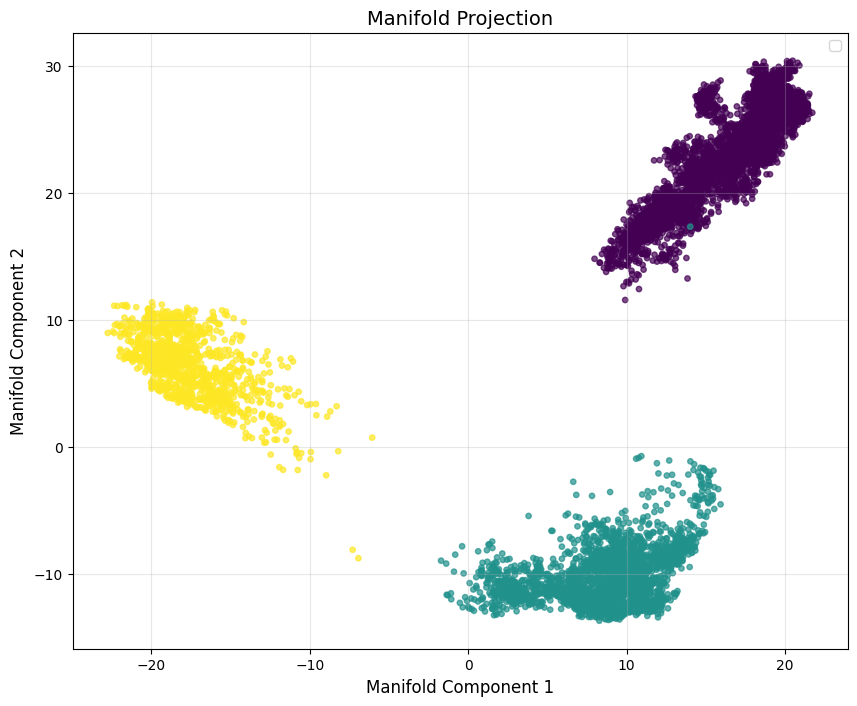

In [126]:
for epoch in range(3):
    new_classifier.train()
    for x, y in train_dataloader:
        optimizer.zero_grad()
        output, _ = new_classifier(x)
        loss = criterion(output, y.squeeze())
        loss.backward()
        optimizer.step()

    new_classifier.eval()
    total_correct = 0
    with torch.no_grad():
        for x, y in test_dataloader:
            output, _ = new_classifier(x)
            predicted = torch.argmax(output, dim=1)
            total_correct += (predicted == y).sum().item()
    accuracy = total_correct / len(test_dataset)
    if epoch%1==0:
        print(f'Epoch {epoch+1}, Test Accuracy: {accuracy:.4f}')
        print(f'Epoch {epoch+1}, last training loss: {loss:.4f}')

all_X_scaled = train_scaler.transform(X)
all_X_scaled = torch.Tensor(all_X_scaled).float()
new_classifier.eval()
all_preds, manifold = new_classifier(all_X_scaled)
all_preds = (torch.sigmoid(output.squeeze()) > 0.5).long()
manifold = manifold.numpy()

plt.figure(figsize=(10, 8))
plt.scatter(manifold[:, 0], manifold[:, 1], c=Y.numpy().astype(int), s=15, alpha=0.7)
plt.title('Manifold Projection', fontsize=14)
plt.xlabel('Manifold Component 1', fontsize=12)
plt.ylabel('Manifold Component 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



# Unbalacing:

In [127]:
# creating a dataset:
state = SimState()

X = []
Y = []
for _ in range(5000):
    row = generate_row(state, NORMAL)
    X.append(torch.Tensor(list(row.values())[:-1]).float())
    Y.append(torch.tensor([0]).long())
for _ in range(500):
    row = generate_row(state, ANOMALY)
    X.append(torch.Tensor(list(row.values())[:-1]).float())
    Y.append(torch.tensor([1]).long())
for _ in range(100):
    row = generate_row(state, ATTACK)
    X.append(torch.Tensor(list(row.values())[:-1]).float())
    Y.append(torch.tensor([2]).long())

X = torch.vstack(X)
Y = torch.vstack(Y)

/tmp/ipykernel_5360/3508481765.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(Y_train).long())
/tmp/ipykernel_5360/3508481765.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(Y_test).long())


Epoch 1, Test Accuracy: 28.4571
Epoch 1, last training loss: 0.6376
Epoch 2, Test Accuracy: 25.9839
Epoch 2, last training loss: 0.5525
Epoch 3, Test Accuracy: 25.9839
Epoch 3, last training loss: 0.5516


/tmp/ipykernel_5360/3508481765.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


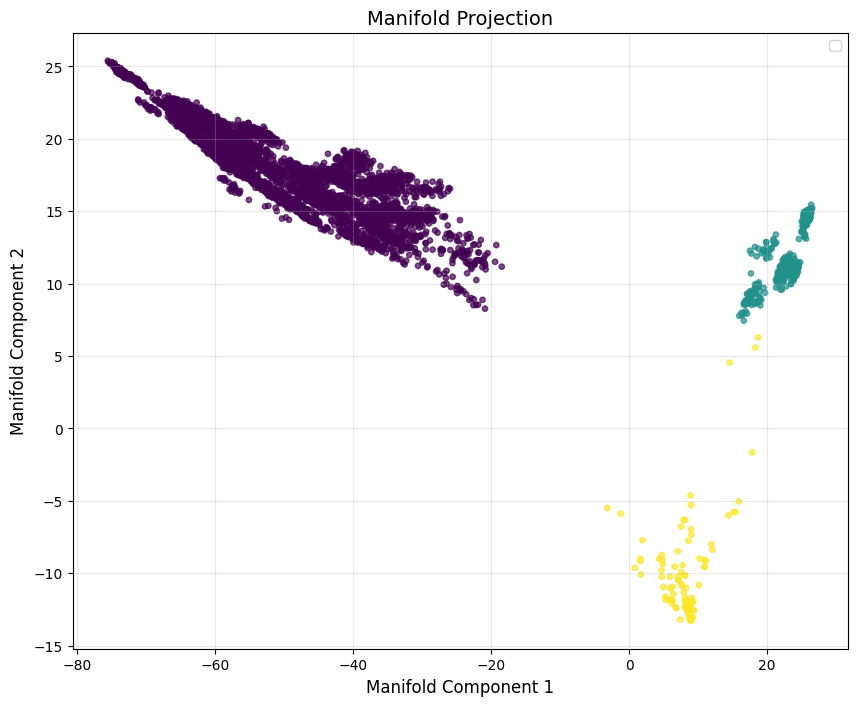

In [86]:
new_classifier = MLP(
    **{
        'input_dim': X.shape[1],
        'output_dim': 3,
        'layer_norm': True,
        'mode':'OF'})

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

train_scaler = MinMaxScaler()
X_train_scaled = train_scaler.fit_transform(X_train)
X_test_scaled = train_scaler.transform(X_test)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(new_classifier.parameters(), lr=0.001)

train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_train_scaled).float(),
    torch.tensor(Y_train).long())
test_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_test_scaled).float(),
    torch.tensor(Y_test).long())

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=False)


for epoch in range(3):
    new_classifier.train()
    for x, y in train_dataloader:
        optimizer.zero_grad()
        output, _ = new_classifier(x)
        loss = criterion(output, y.squeeze())
        loss.backward()
        optimizer.step()

    new_classifier.eval()
    total_correct = 0
    with torch.no_grad():
        for x, y in test_dataloader:
            output, _ = new_classifier(x)
            predicted = torch.argmax(output, dim=1)
            total_correct += (predicted == y).sum().item()
    accuracy = total_correct / len(test_dataset)
    if epoch%1==0:
        print(f'Epoch {epoch+1}, Test Accuracy: {accuracy:.4f}')
        print(f'Epoch {epoch+1}, last training loss: {loss:.4f}')

all_X_scaled = train_scaler.transform(X)
all_X_scaled = torch.Tensor(all_X_scaled).float()
new_classifier.eval()
all_preds, manifold = new_classifier(all_X_scaled)
all_preds = (torch.sigmoid(output.squeeze()) > 0.5).long()
manifold = manifold.numpy()

plt.figure(figsize=(10, 8))
plt.scatter(manifold[:, 0], manifold[:, 1], c=Y.numpy().astype(int), s=15, alpha=0.7)
plt.title('Manifold Projection', fontsize=14)
plt.xlabel('Manifold Component 1', fontsize=12)
plt.ylabel('Manifold Component 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

